In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

Una vez limpio diciembre y juntado con Noviembre
se abre el archivo unificado y se vuelve a tirar sobre el codigo de limpieza 
y análisis total de todo el contenido.
Y al obtener dias festivos añadimos festividades ala tabla. 

- https://www.eurowings.com/es/informar/sobre-nosotros/tecnologia-y-flota.html
- https://www.flightaware.com/live/flight/EWG9443/history/20251121/1845Z/LEBL/EDDL
- https://www.aeropuertobarcelona-elprat.com/cast/salidas-aeropuerto-barcelona.html?t=9-12&a=2

In [2]:
df = pd.read_csv("vuelos_Enero_Noviembre.csv")
df

,Unnamed: 0,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [3]:
df.isna().sum()[df.isna().sum() > 0] 

Series([], dtype: int64)

In [4]:
df = df.drop(columns= ['Unnamed: 0'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2703 entries, 0 to 2702
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   fecha_scrapeo    2703 non-null   object
 1   Name_company     2703 non-null   object
 2   Num_flight       2703 non-null   object
 3   Name_Destiny     2703 non-null   object
 4   Time_flight      2703 non-null   object
 5   flight_state     2703 non-null   object
 6   flight_capacity  2703 non-null   int64 
 7   Aircraft         2703 non-null   object
 8   Gate             2703 non-null   object
 9   Type_f           2703 non-null   object
 10  week_day         2703 non-null   object
 11  day_time         2703 non-null   object
dtypes: int64(1), object(11)
memory usage: 253.5+ KB


In [6]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [7]:
df[df.Gate == 'Y']

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
8,2025-11-17,Grupo Ryanair,FR8215,London (STN),06:45:00,En hora,197,Boeing 737 MAX 8,Y,INT,Lunes,Mañana
22,2025-11-17,Air Arabia Maroc,3O398,Rabat (RBA),09:20:00,En hora,174,Airbus A320,Y,INT,Lunes,Mañana
43,2025-11-17,Grupo Ryanair,FR7808,London (LTN),10:35:00,En hora,197,Boeing 737 MAX 8,Y,INT,Lunes,Mañana
46,2025-11-17,Grupo Ryanair,FR2239,Marrakech (RAK),10:45:00,En hora,189,Boeing 737-800,Y,INT,Lunes,Mañana
52,2025-11-17,FLYONE Armenia,3F232,Yerevan (EVN),11:30:00,En hora,180,Airbus A320,Y,INT,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2661,2025-12-07,Grupo Ryanair,FR2233,Al Aaroui (NDR),19:40:00,En hora,189,Boeing 737-800,Y,INT,Domingo,Tarde
2674,2025-12-07,Air Serbia,JU585,Belgrade (BEG),20:35:00,En hora,174,Airbus A320,Y,INT,Domingo,Noche
2686,2025-12-07,Aer Lingus,EI565,Dublin (DUB),21:05:00,En hora,174,Airbus A320,Y,INT,Domingo,Noche
2689,2025-12-07,Grupo Ryanair,FR3792,Birmingham (BHX),21:20:00,En hora,189,Boeing 737-800,Y,INT,Domingo,Noche


In [8]:
df.loc[
(df['Aircraft'] == 'DBoeing 737-800'), 
'Aircraft'
] = 'Boeing 737-800'

In [9]:
df.loc[
(df['Aircraft'] == 'De Havilland Dash 8-400'), 
'Aircraft'
] = 'de Havilland Dash 8-400'

# estandarizar 

In [10]:
df.loc[
(df['Name_Destiny'] == 'Palma De Mallorca (PMI)'), 
'Name_Destiny'
] = 'Palma de Mallorca (PMI)'

# estandarizar 

In [11]:
# AÑADIR COLUMNA DE F_TYPE
df['Aircraft'].unique()   # ESTANDARIZAR ESTO 

array(['Boeing 737-800', 'Airbus A319', 'Boeing 737 MAX 8', 'Airbus A320',
       'Airbus A321neo', 'Airbus A321', 'Airbus A320neo',
       'de Havilland Dash 8-400', 'Airbus A220-300', 'Airbus A330-200',
       'Airbus A330-800', 'Boeing 737-700', 'Airbus A350-900',
       'BOEING 777-300ER', 'Airbus A330-900', 'Boeing 757-200',
       'Embraer ERJ-190'], dtype=object)

In [12]:
# AÑADIR COLUMNA DE F_TYPE
df['Gate'].unique()   # ESTANDARIZAR ESTO 

array(['U', 'S', 'R', 'W', 'Y', 'M'], dtype=object)

In [13]:
df[(df.Name_Destiny == 'Valletta (MLA)')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
163,2025-11-17,Grupo Ryanair,FR1527,Valletta (MLA),21:50:00,Retrasado,197,Boeing 737 MAX 8,S,EU,Lunes,Noche
442,2025-11-20,Grupo Ryanair,FR1527,Valletta (MLA),21:20:00,En hora,189,Boeing 737-800,U,EU,Jueves,Noche
465,2025-11-21,Grupo Ryanair,FR5752,Valletta (MLA),08:40:00,En hora,197,Boeing 737 MAX 8,U,EU,Viernes,Mañana
579,2025-11-21,Grupo Ryanair,FR1527,Valletta (MLA),20:05:00,En hora,189,Boeing 737-800,U,EU,Viernes,Noche
694,2025-11-22,Grupo Ryanair,FR5752,Valletta (MLA),17:10:00,En hora,197,Boeing 737 MAX 8,U,EU,Sábado,Tarde
786,2025-11-23,Grupo Ryanair,FR1527,Valletta (MLA),12:30:00,En hora,189,Boeing 737-800,U,EU,Domingo,Tarde
886,2025-11-23,Grupo Ryanair,FR5752,Valletta (MLA),21:45:00,Retrasado,197,Boeing 737 MAX 8,S,EU,Domingo,Noche
1054,2025-11-24,Grupo Ryanair,FR1527,Valletta (MLA),21:50:00,Retrasado,197,Boeing 737 MAX 8,S,EU,Lunes,Noche
1326,2025-11-27,Grupo Ryanair,FR1527,Valletta (MLA),21:20:00,Retrasado,189,Boeing 737-800,U,EU,Jueves,Noche
1349,2025-11-28,Grupo Ryanair,FR5752,Valletta (MLA),08:40:00,Retrasado,197,Boeing 737 MAX 8,U,EU,Viernes,Mañana


In [14]:
df[(df.Gate == 'M')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
42,2025-11-17,Grupo easy,U22324,London (LTN),10:25:00,Retrasado,186,Airbus A320neo,M,INT,Lunes,Mañana
45,2025-11-17,Grupo easy,U28056,London (LGW),10:40:00,Retrasado,180,Airbus A320,M,INT,Lunes,Mañana
51,2025-11-17,Grupo easy,U22002,Manchester (MAN),11:20:00,Retrasado,180,Airbus A320,M,INT,Lunes,Mañana
104,2025-11-17,Grupo easy,U23372,Liverpool (LPL),17:00:00,En hora,156,Airbus A319,M,INT,Lunes,Tarde
130,2025-11-17,Grupo easy,U28058,London (LGW),19:45:00,En hora,156,Airbus A319,M,INT,Lunes,Tarde
...,...,...,...,...,...,...,...,...,...,...,...,...
2652,2025-12-07,Grupo easy,U25716,Southend (SEN),18:55:00,Retrasado,186,Airbus A320neo,M,INT,Domingo,Tarde
2665,2025-12-07,Grupo easy,U28058,London (LGW),19:45:00,En hora,180,Airbus A320,M,INT,Domingo,Tarde
2683,2025-12-07,Grupo easy,U22326,London (LTN),20:55:00,En hora,186,Airbus A320neo,M,INT,Domingo,Noche
2692,2025-12-07,Grupo easy,U28060,London (LGW),21:30:00,En hora,156,Airbus A319,M,INT,Domingo,Noche


In [15]:
'Palma de Mallorca (PMI)' 'Palma De Mallorca (PMI)'

'Palma de Mallorca (PMI)Palma De Mallorca (PMI)'

In [16]:
# AÑADIR COLUMNA DE F_TYPE
df['Name_Destiny'].unique()

array(['Rome (FCO)', 'Milan (BGY)', 'Geneva (GVA)', 'Al Aaroui (NDR)',
       'Budapest (BUD)', 'Lisbon (LIS)', 'London (LGW)', 'Krakow (KRK)',
       'London (STN)', 'Strasbourg (SXB)', 'Milan (MXP)', 'Ibiza (IBZ)',
       'Palma de Mallorca (PMI)', 'Sevilla (SVQ)', 'Copenhagen (CPH)',
       'Napoli (NAP)', 'Bologna (BLQ)', 'Vienna (VIE)',
       'Ouarzazate (OZZ)', 'Rabat (RBA)', 'Stuttgart (STR)',
       'Bucharest (OTP)', 'Tirana (TIA)', 'Asturias (OVD)',
       'Basel, Switzerland/Mulhouse (BSL)', 'Charleroi (CRL)',
       'Rotterdam (RTM)', 'Dusseldorf (DUS)', 'Porto (OPO)',
       'Belgrade (BEG)', 'Amsterdam (AMS)', 'Paris (ORY)',
       'Liverpool (LPL)', 'Warsaw (WAW)', 'London (LTN)',
       "Nice/Cote D'Azur (NCE)", 'Marrakech (RAK)', 'Beauvais (BVA)',
       'Dublin (DUB)', 'Prague (PRG)', 'Manchester (MAN)',
       'Yerevan (EVN)', 'Birmingham (BHX)', 'Venice (VCE)',
       'Leeds Bradford (LBA)', 'Torino (TRN)', 'Istanbul (SAW)',
       'Lyon (LYS)', 'Bratislava (BTS)',

In [17]:
df["Gate"] = df["Gate"].str.extract(r'([A-Za-z]+)') # dejar solo letra

In [18]:
# LISTA DE AEROPUERTOS NACIONALES
"""
vue_nac = ['Ibiza (IBZ)', 'Palma de Mallorca (PMI)', 'Sevilla (SVQ)', 
           'Malaga (AGP)', 'Asturias (OVD)', 'Murcia (RMU)', 'Vitoria (VIT)', 
           'Palmerola (XPL)'] 
puertas = ['Y', 'W', 'M']  # PUERTAS DE VUELOS QUE TIENES QUE PASAR CONTROL DE PASAPORTES 
fin = []
for gate, name in zip(df['Gate'], df['Name_Destiny']):
    if pd.isnull(gate):
        fin.append(np.nan)
    elif gate in puertas:
        fin.append("INT")
    elif name in vue_nac:
        fin.append("NAC")
    else:
        fin.append("EU")
print(fin)
"""

'\nvue_nac = [\'Ibiza (IBZ)\', \'Palma de Mallorca (PMI)\', \'Sevilla (SVQ)\', \n           \'Malaga (AGP)\', \'Asturias (OVD)\', \'Murcia (RMU)\', \'Vitoria (VIT)\', \n           \'Palmerola (XPL)\'] \npuertas = [\'Y\', \'W\', \'M\']  # PUERTAS DE VUELOS QUE TIENES QUE PASAR CONTROL DE PASAPORTES \nfin = []\nfor gate, name in zip(df[\'Gate\'], df[\'Name_Destiny\']):\n    if pd.isnull(gate):\n        fin.append(np.nan)\n    elif gate in puertas:\n        fin.append("INT")\n    elif name in vue_nac:\n        fin.append("NAC")\n    else:\n        fin.append("EU")\nprint(fin)\n'

In [19]:
#df['Type_f'] = fin # guardo la variable en la columna nueva

In [20]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [21]:
# convertir en string ya que habia mezcla
df["fecha_scrapeo"] = df["fecha_scrapeo"].astype(str)

In [22]:
#s = '16/11/2025 23-03-05'
#s.split(" ")[0]

In [23]:
#s = '16/11/2025'
#s.split(" ")[0]

In [24]:
# QUITAR LA HORA 
#f = lambda x: x.split(" ")[0]
#df["fecha_scrapeo"] = df["fecha_scrapeo"].apply(f)

#df["fecha_scrapeo"] = df["fecha_scrapeo"].str.strip(" ")[0]

In [25]:
df.tail()

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche
2702,2025-12-07,Grupo Ryanair,FR9406,Fes (FEZ),23:15:00,En hora,189,Boeing 737-800,Y,INT,Domingo,Noche


In [26]:
# Convertir a datetime con el dia como primero 
#df["fecha_scrapeo"] = pd.to_datetime(df["fecha_scrapeo"],
 #                                    format="%d/%m/%Y", # especificar formato %d/%m/%Y
 #                                    errors="coerce"
 #                                   )
# Estandarizar al formato deseado: 16/12/2025
#df["fecha_scrapeo"] = df["fecha_scrapeo"].dt.strftime("%d/%m/%Y")

In [27]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2703 entries, 0 to 2702
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   fecha_scrapeo    2703 non-null   object
 1   Name_company     2703 non-null   object
 2   Num_flight       2703 non-null   object
 3   Name_Destiny     2703 non-null   object
 4   Time_flight      2703 non-null   object
 5   flight_state     2703 non-null   object
 6   flight_capacity  2703 non-null   int64 
 7   Aircraft         2703 non-null   object
 8   Gate             2703 non-null   object
 9   Type_f           2703 non-null   object
 10  week_day         2703 non-null   object
 11  day_time         2703 non-null   object
dtypes: int64(1), object(11)
memory usage: 253.5+ KB


In [29]:
df["flight_capacity"] = df["flight_capacity"].astype('Int64')

In [30]:
df['flight_capacity'].tail(40)

2663    189
2664    189
2665    180
2666    230
2667    189
2668    239
2669    180
2670    189
2671    239
2672    197
2673    180
2674    174
2675    189
2676    232
2677    189
2678    141
2679    189
2680    239
2681    189
2682    189
2683    186
2684    239
2685    189
2686    174
2687    189
2688    189
2689    189
2690    230
2691    180
2692    156
2693    239
2694    197
2695    230
2696    180
2697    180
2698    239
2699    230
2700    189
2701    239
2702    189
Name: flight_capacity, dtype: Int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2703 entries, 0 to 2702
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   fecha_scrapeo    2703 non-null   object
 1   Name_company     2703 non-null   object
 2   Num_flight       2703 non-null   object
 3   Name_Destiny     2703 non-null   object
 4   Time_flight      2703 non-null   object
 5   flight_state     2703 non-null   object
 6   flight_capacity  2703 non-null   Int64 
 7   Aircraft         2703 non-null   object
 8   Gate             2703 non-null   object
 9   Type_f           2703 non-null   object
 10  week_day         2703 non-null   object
 11  day_time         2703 non-null   object
dtypes: Int64(1), object(11)
memory usage: 256.2+ KB


In [32]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [33]:
f = lambda x: x.split(", ")[0]
df["flight_state"] = df["flight_state"].apply(f)
# quedarme con lo primero de esa columna

In [34]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [35]:
df['flight_state'].value_counts()

flight_state
En hora      2022
Retrasado     681
Name: count, dtype: int64

In [36]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [37]:
"""
df["fecha_scrapeo"] = pd.to_datetime(
    df["fecha_scrapeo"],
    format="%d/%m/%Y",
    dayfirst=True
)
"""

'\ndf["fecha_scrapeo"] = pd.to_datetime(\n    df["fecha_scrapeo"],\n    format="%d/%m/%Y",\n    dayfirst=True\n)\n'

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2703 entries, 0 to 2702
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   fecha_scrapeo    2703 non-null   object
 1   Name_company     2703 non-null   object
 2   Num_flight       2703 non-null   object
 3   Name_Destiny     2703 non-null   object
 4   Time_flight      2703 non-null   object
 5   flight_state     2703 non-null   object
 6   flight_capacity  2703 non-null   Int64 
 7   Aircraft         2703 non-null   object
 8   Gate             2703 non-null   object
 9   Type_f           2703 non-null   object
 10  week_day         2703 non-null   object
 11  day_time         2703 non-null   object
dtypes: Int64(1), object(11)
memory usage: 256.2+ KB


In [39]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [40]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'].isin(['U', 'S']))]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [41]:
# LISTA DE 
"""
compi = ["Ryanair", "BUZZ", "Lauda Europe", "Ryanair UK"]
easy = ["easyJet Europe", "Easyjet"]
wizz = ["Wizz Air", "Wizz Air Malta"]
#norw = ["Norwegian Air Shuttle", "Norwegian Air Sweden AOC"]
grupo = []
for x in df['Name_company']:
    if x in compi:
        grupo.append("Grupo Ryanair")
    elif x in easy:
        grupo.append("Grupo easy")
    elif x in wizz:
        grupo.append("Grupo wizz")
    #elif x in norw:
        #grupo.append("Grupo Norwegian")
    else:
        grupo.append(x)
print(grupo)
"""

'\ncompi = ["Ryanair", "BUZZ", "Lauda Europe", "Ryanair UK"]\neasy = ["easyJet Europe", "Easyjet"]\nwizz = ["Wizz Air", "Wizz Air Malta"]\n#norw = ["Norwegian Air Shuttle", "Norwegian Air Sweden AOC"]\ngrupo = []\nfor x in df[\'Name_company\']:\n    if x in compi:\n        grupo.append("Grupo Ryanair")\n    elif x in easy:\n        grupo.append("Grupo easy")\n    elif x in wizz:\n        grupo.append("Grupo wizz")\n    #elif x in norw:\n        #grupo.append("Grupo Norwegian")\n    else:\n        grupo.append(x)\nprint(grupo)\n'

In [42]:
#df['Name_company'] = grupo

In [43]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [44]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'].isin(['U', 'S']))]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [45]:
#df.groupby(['fecha_scrapeo', 'Name_company', ''])

In [46]:
dest_counts = df["Aircraft"].value_counts()
top40 = dest_counts.head(30)
top40_sorted = top40.sort_values(ascending=True)

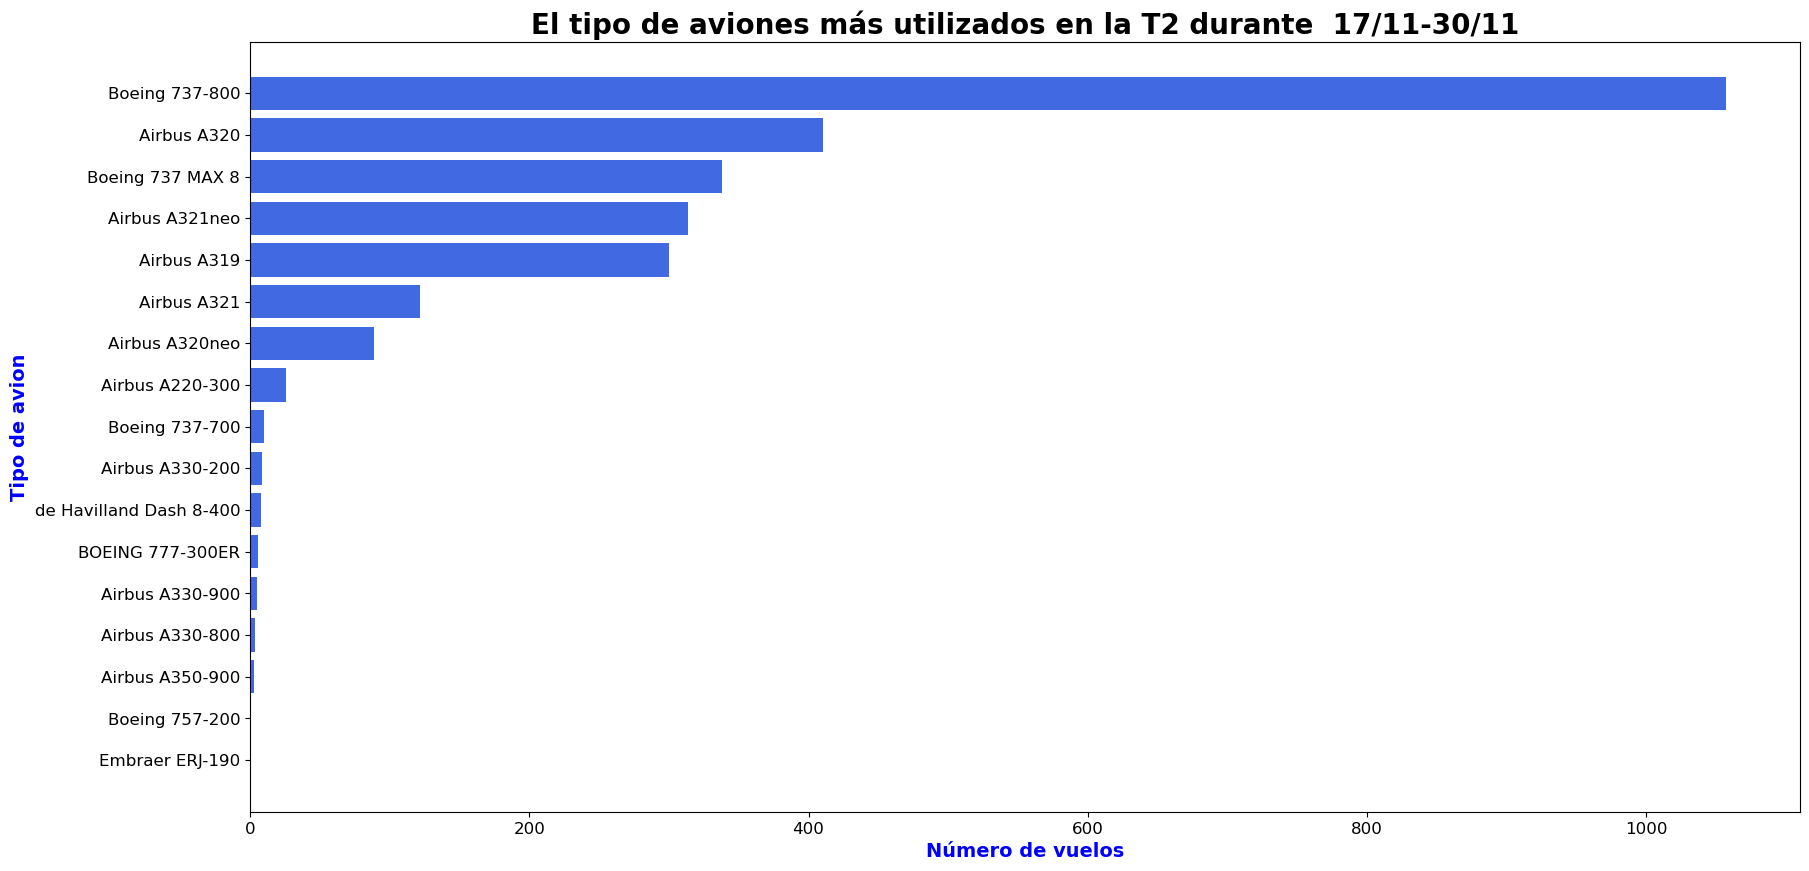

In [47]:
plt.figure(figsize=(20,10))
plt.barh(top40_sorted.index, top40_sorted.values, color="royalblue")

plt.title("El tipo de aviones más utilizados en la T2 durante  17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [48]:
dest_counts = df["Type_f"].value_counts()
top41 = dest_counts.head(30)
top41_sorted = top41.sort_values(ascending=True)

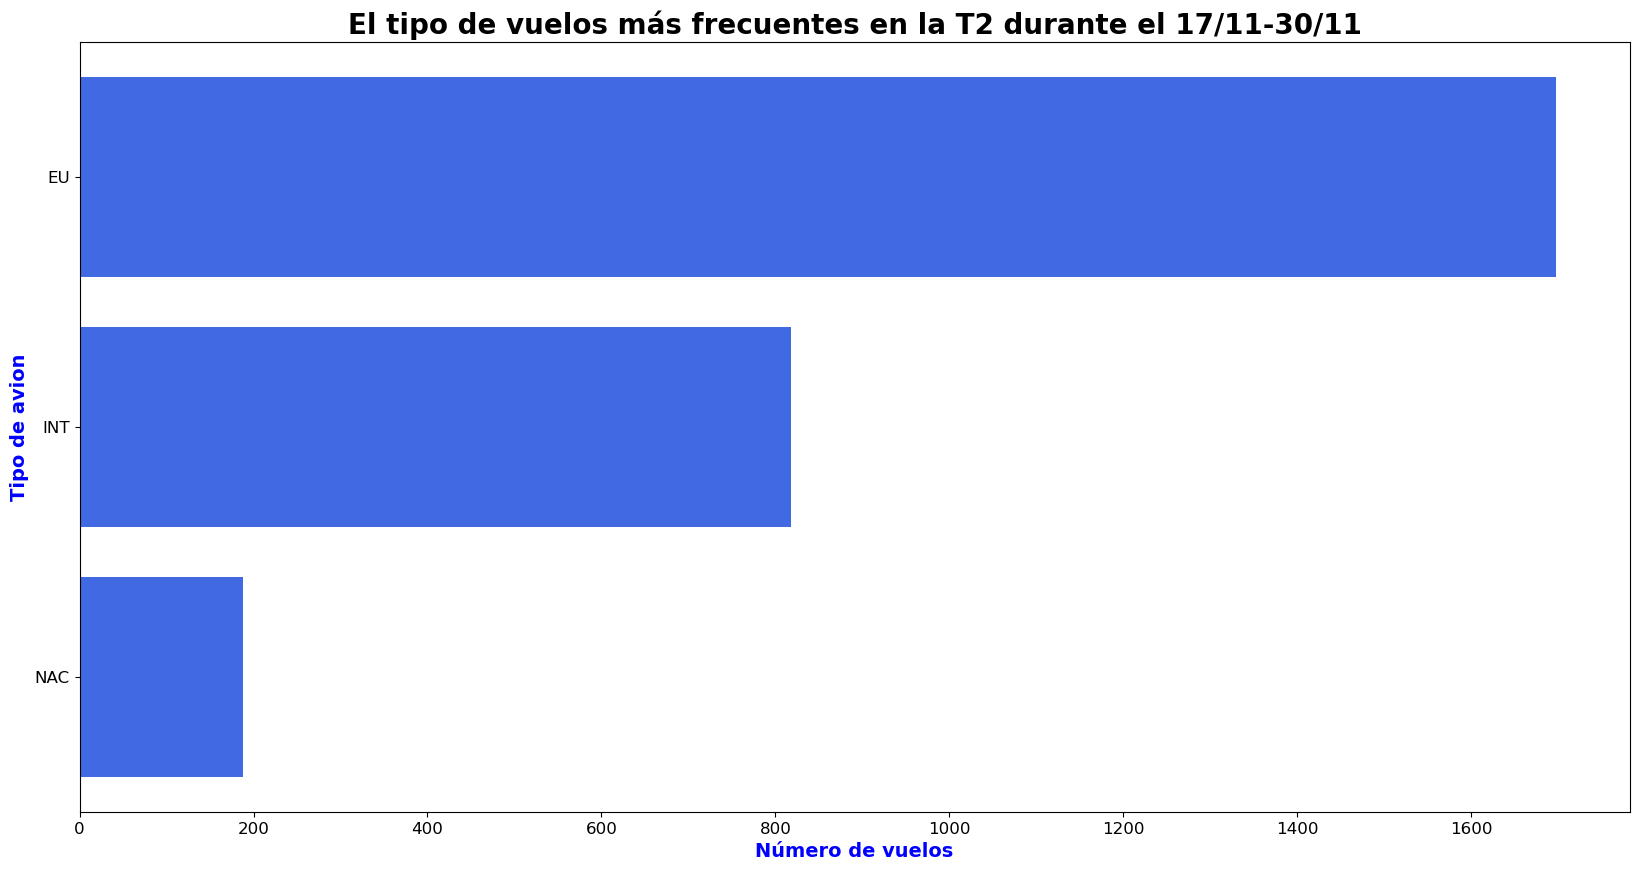

In [49]:
plt.figure(figsize=(20,10))
plt.barh(top41_sorted.index, top41_sorted.values, color="royalblue")

plt.title("El tipo de vuelos más frecuentes en la T2 durante el 17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [50]:
df["Type_f"].unique()

array(['EU', 'INT', 'NAC'], dtype=object)

In [51]:
"""
compi = ["Programado", "En hora", "Ha salido"]
easy = ["Retrasado"]

est = []
for x in df['flight_state']:
    if x in compi: 
        est.append("En hora")
    elif x in easy:
        est.append("Retrasado")
print(est)
# objetivo de unificar y estandarizar 
"""

'\ncompi = ["Programado", "En hora", "Ha salido"]\neasy = ["Retrasado"]\n\nest = []\nfor x in df[\'flight_state\']:\n    if x in compi: \n        est.append("En hora")\n    elif x in easy:\n        est.append("Retrasado")\nprint(est)\n# objetivo de unificar y estandarizar \n'

In [52]:
#df['flight_state'] = est

In [53]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [54]:
dest_counts = df["flight_state"].value_counts()
top42 = dest_counts.head(30)
top42_sorted = top42.sort_values(ascending=True)

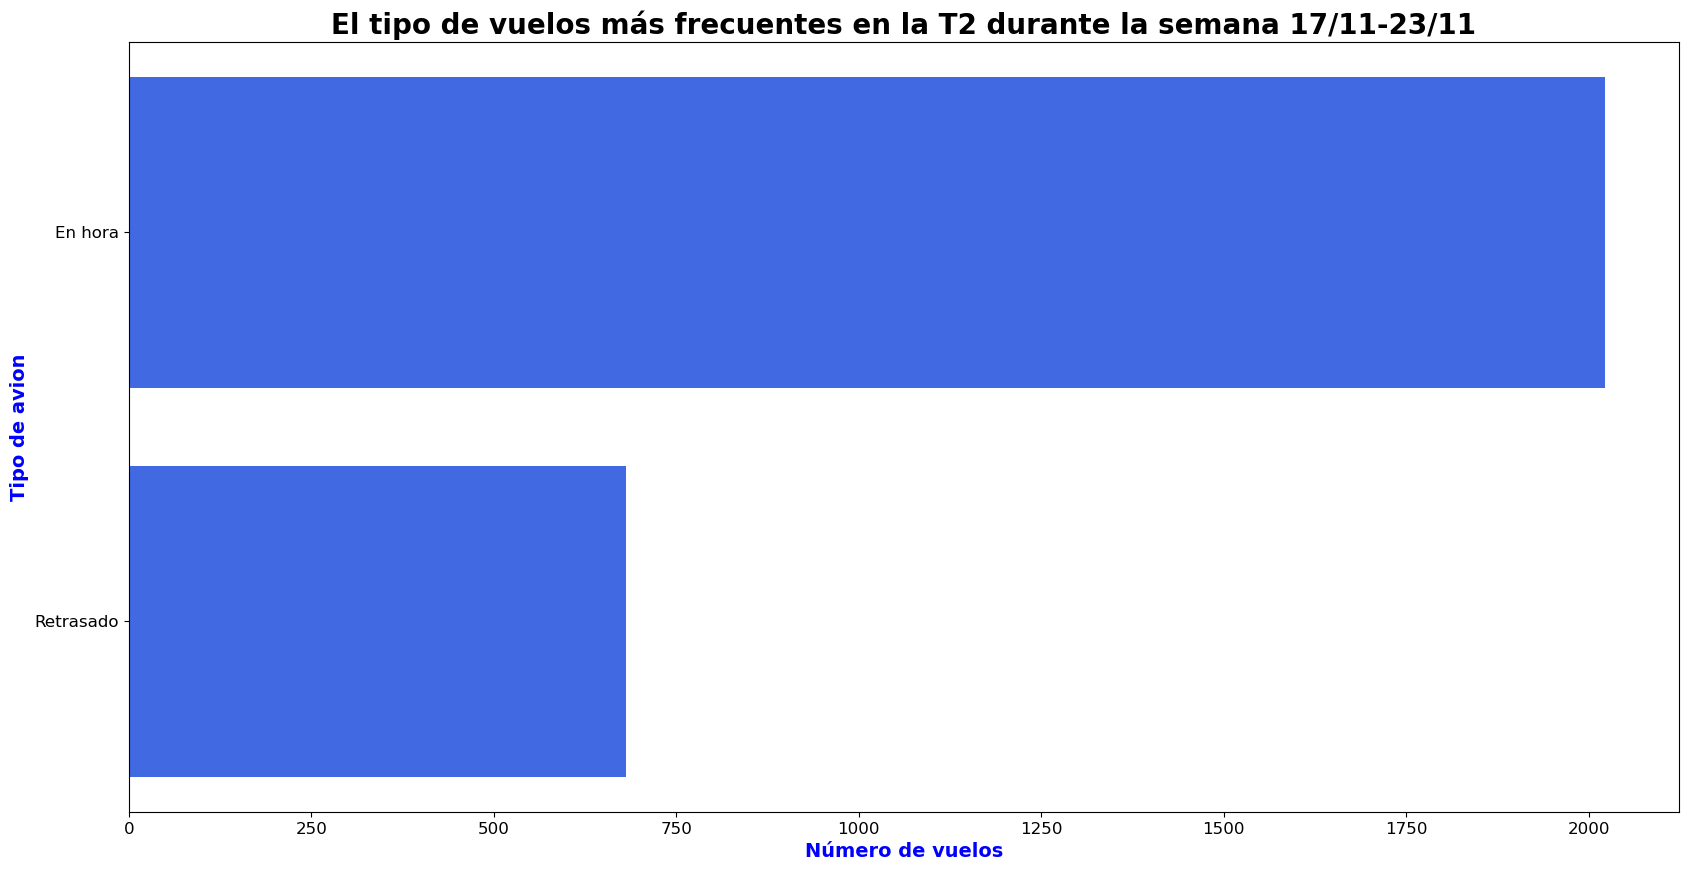

In [55]:
plt.figure(figsize=(20,10))
plt.barh(top42_sorted.index, top42_sorted.values, color="royalblue")

plt.title("El tipo de vuelos más frecuentes en la T2 durante la semana 17/11-23/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

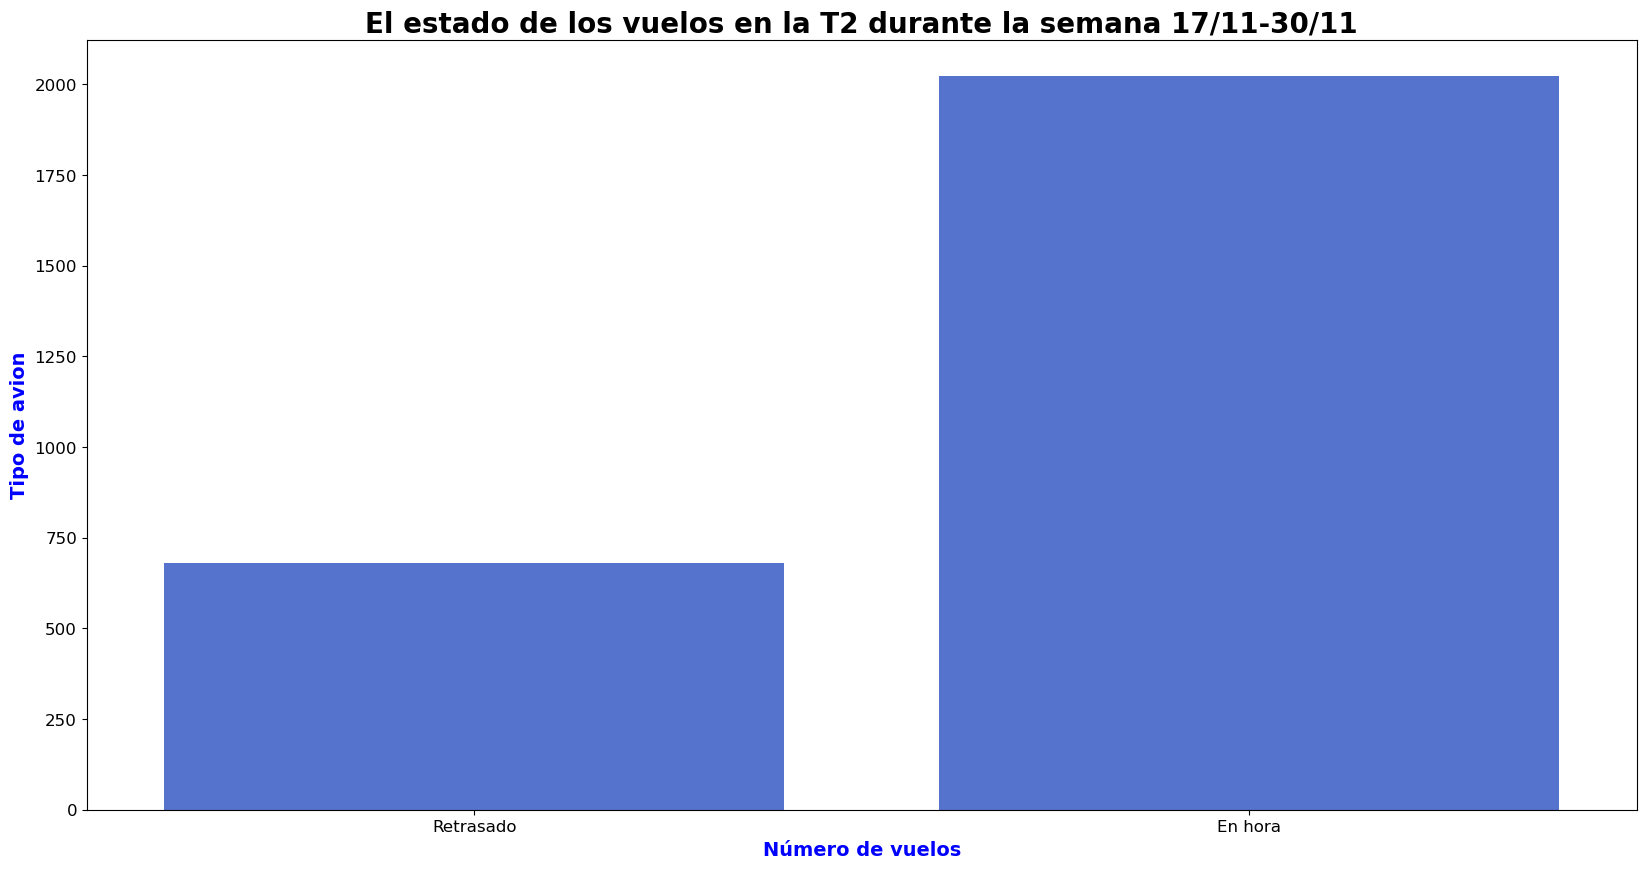

In [56]:
plt.figure(figsize=(20,10))

#sns.barplot(x=df['fecha_scrapeo'], y=top42_sorted, color="royalblue")
sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="royalblue")
#sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="red")

plt.title("El estado de los vuelos en la T2 durante la semana 17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [57]:
dest_counts = df["Gate"].value_counts()
top43 = dest_counts.head(30)
top43_sorted = top43.sort_values(ascending=True)

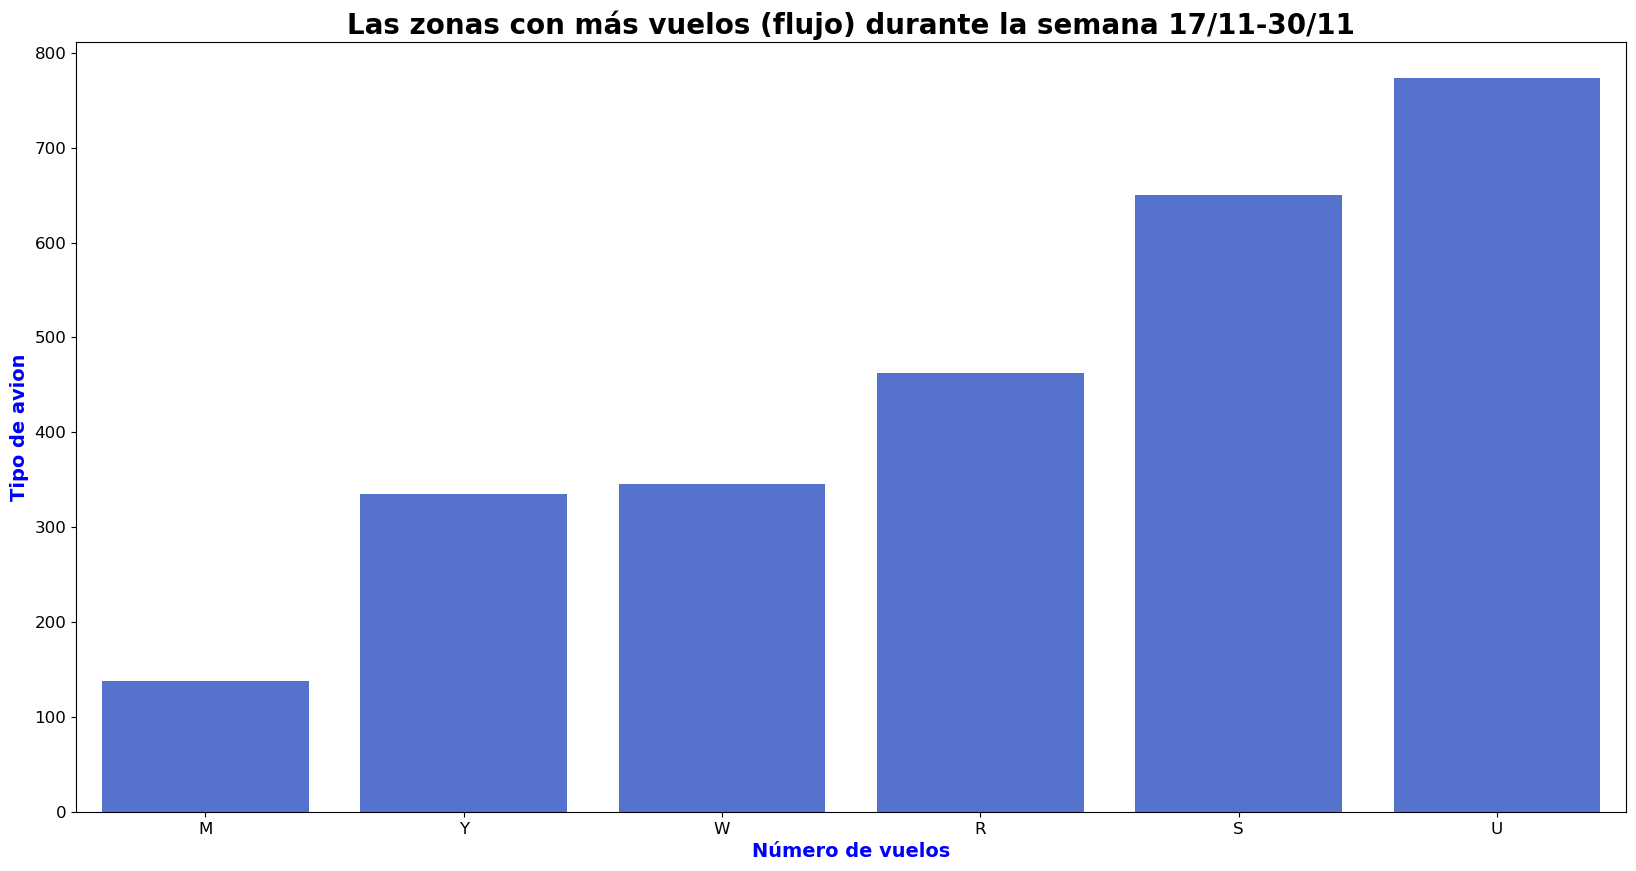

In [58]:
plt.figure(figsize=(20,10))

#sns.barplot(x=df['fecha_scrapeo'], y=top42_sorted, color="royalblue")
sns.barplot(x=top43_sorted.index, y=top43_sorted.values, color="royalblue")
#sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="red")

plt.title("Las zonas con más vuelos (flujo) durante la semana 17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [59]:
dest_counts = df["Name_company"].value_counts()
top44 = dest_counts.head(30)
top44_sorted = top44.sort_values(ascending=True)

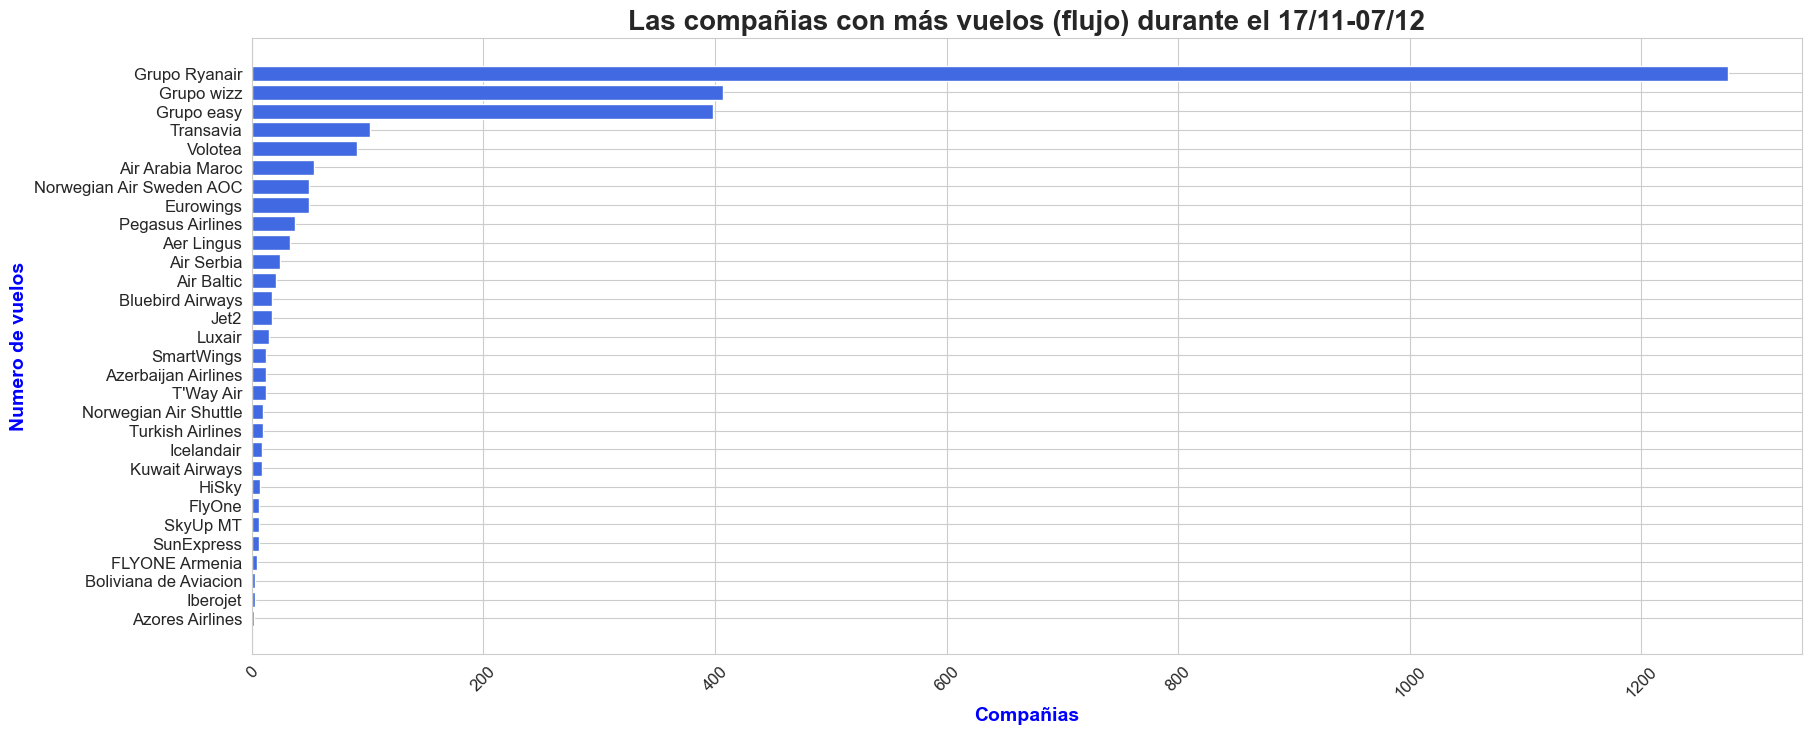

In [60]:
sns.set_style("whitegrid")  # Estilo de fondo
sns.set_palette("tab10") 

plt.figure(figsize=(20,8))

#sns.barplot(x=df['fecha_scrapeo'], y=top42_sorted, color="royalblue")
plt.barh(top44_sorted.index, top44_sorted.values, color="royalblue")
#sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="red")

plt.title("Las compañias con más vuelos (flujo) durante el 17/11-07/12", fontsize=20, weight='bold')
plt.xlabel("Compañias", fontsize=14, weight='bold', color='blue')
plt.ylabel("Numero de vuelos", fontsize=14, weight='bold', color='blue')

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [61]:
#df['Time_flight'] = pd.to_datetime(df['Time_flight'].astype(str), format="%H:%M").dt.time
#df['hora'] = pd.to_datetime(df['hora'].astype(str), format='%H:%M:%S').dt.time

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2703 entries, 0 to 2702
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   fecha_scrapeo    2703 non-null   object
 1   Name_company     2703 non-null   object
 2   Num_flight       2703 non-null   object
 3   Name_Destiny     2703 non-null   object
 4   Time_flight      2703 non-null   object
 5   flight_state     2703 non-null   object
 6   flight_capacity  2703 non-null   Int64 
 7   Aircraft         2703 non-null   object
 8   Gate             2703 non-null   object
 9   Type_f           2703 non-null   object
 10  week_day         2703 non-null   object
 11  day_time         2703 non-null   object
dtypes: Int64(1), object(11)
memory usage: 256.2+ KB


In [63]:
# Time_flight      851 non-null    object   convertir en datetime
# añadir columna weed_day

In [64]:
df.head()

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana


In [65]:
# DEJA EL RESTO DE FILAS EXCESPTO LAS QUE TENGAN ESA FECHA 
#df = df[df['fecha_scrapeo'] != '2025-11-16']

In [66]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [67]:
type(df['Time_flight'].iloc[0])

str

In [68]:
#df['week_day'] = df['fecha_scrapeo'].dt.day_name(locale='es_ES')

In [69]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [70]:
"""
dest_counts = df["week_day"].value_counts()

orden_semana = [
    'Lunes', 'Martes', 'Miércoles', 'Jueves',
    'Viernes', 'Sábado', 'Domingo'
]

# Convertimos el índice a categoría ordenada
dest_counts.index = pd.Categorical(dest_counts.index, categories=orden_semana, ordered=True)

# ordenar
top4_sorted = dest_counts.sort_index()
"""

'\ndest_counts = df["week_day"].value_counts()\n\norden_semana = [\n    \'Lunes\', \'Martes\', \'Miércoles\', \'Jueves\',\n    \'Viernes\', \'Sábado\', \'Domingo\'\n]\n\n# Convertimos el índice a categoría ordenada\ndest_counts.index = pd.Categorical(dest_counts.index, categories=orden_semana, ordered=True)\n\n# ordenar\ntop4_sorted = dest_counts.sort_index()\n'

In [71]:
df_counts = df.groupby(["fecha_scrapeo", "week_day"]).size().reset_index(name="n_vuelos")


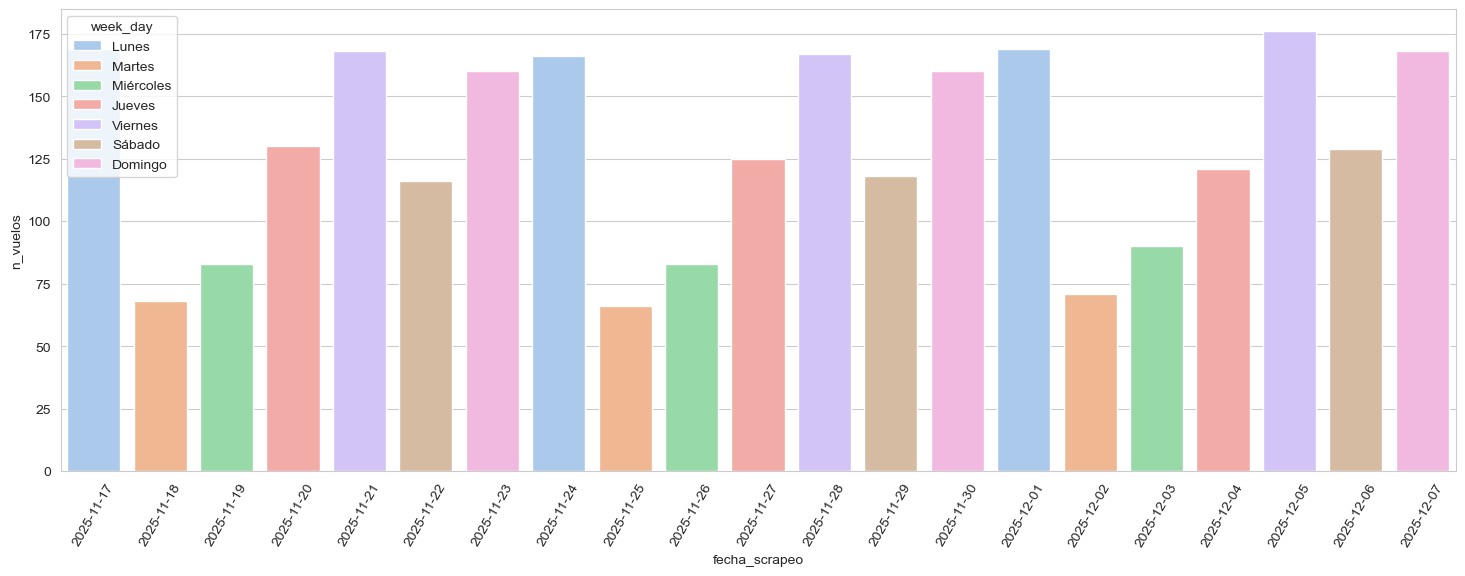

In [72]:
plt.figure(figsize=(18,6))
sns.barplot(
    data=df_counts,
    x="fecha_scrapeo",
    y="n_vuelos",
    hue="week_day",
    palette="pastel"
)
plt.xticks(rotation=60)
plt.show()


In [73]:
df[(df['Aircraft'] == 'Airbus A319') & (df['Name_company'] == 'Eurowings')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
189,2025-11-18,Eurowings,EW9441,Dusseldorf (DUS),09:45:00,En hora,150,Airbus A319,S,EU,Martes,Mañana
253,2025-11-19,Eurowings,EW9441,Dusseldorf (DUS),09:45:00,En hora,150,Airbus A319,S,EU,Miércoles,Mañana
280,2025-11-19,Eurowings,EW2521,Stuttgart (STR),15:10:00,Retrasado,150,Airbus A319,S,EU,Miércoles,Tarde
374,2025-11-20,Eurowings,EW521,Cologne-Bonn (CGN),13:25:00,Retrasado,150,Airbus A319,S,EU,Jueves,Tarde
755,2025-11-23,Eurowings,EW7521,Hamburg (HAM),09:25:00,En hora,150,Airbus A319,S,EU,Domingo,Mañana
851,2025-11-23,Eurowings,EW9443,Dusseldorf (DUS),19:35:00,En hora,150,Airbus A319,U,EU,Domingo,Tarde
917,2025-11-24,Eurowings,EW2521,Stuttgart (STR),09:20:00,Retrasado,150,Airbus A319,S,EU,Lunes,Mañana
1168,2025-11-26,Eurowings,EW2521,Stuttgart (STR),15:10:00,En hora,150,Airbus A319,S,EU,Miércoles,Tarde
1640,2025-11-30,Eurowings,EW7521,Hamburg (HAM),09:25:00,Retrasado,150,Airbus A319,U,EU,Domingo,Mañana
1802,2025-12-01,Eurowings,EW2521,Stuttgart (STR),09:20:00,Retrasado,150,Airbus A319,S,EU,Lunes,Mañana


In [74]:
# CAMBIAR CAPACIDAD A 150 

In [75]:
df.loc[
(df['Aircraft'] == 'Airbus A319') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 150  

In [76]:
df.loc[
(df['Aircraft'] == 'Airbus A320neo') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 180 

In [77]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 180 

In [78]:
df.loc[
(df['Aircraft'] == 'Airbus A321') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 226

In [79]:
df.loc[
(df['Aircraft'] == 'Airbus A321neo') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 232

In [80]:
df.loc[
(df['Aircraft'] == 'Airbus A321neo') & 
(df['Name_company'] == 'Transavia'),
'flight_capacity'
] = 232

In [81]:
df.loc[
(df['Aircraft'] == 'Airbus A319') & 
(df['Name_company'] == 'Air Serbia'),
'flight_capacity'
] = 144 

In [82]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'Air Arabia Maroc'),
'flight_capacity'
] = 174   # si es eurowings y tiene ese tipo de avion ponerle estas capacidades 

In [83]:
df.loc[
(df['Aircraft'] == 'Airbus A321') & 
(df['Name_company'] == 'Pegasus Airlines'),
'flight_capacity'
] = 220   

In [84]:
df.loc[
(df['Aircraft'] == 'Boeing 737 MAX 8') & 
(df['Name_company'] == 'Pegasus Airlines'),
'flight_capacity'
] = 189  

In [85]:
df.loc[
(df['Aircraft'] == 'Boeing 737 MAX 8') & 
(df['Name_company'] == 'Jet2'),
'flight_capacity'
] = 189

In [86]:
df.loc[
(df['Aircraft'] == 'Airbus A321neo') & 
(df['Name_company'] == 'Jet2'),
'flight_capacity'
] = 232 

In [87]:
df.loc[
(df['Aircraft'] == 'Boeing 737 MAX 8') & 
(df['Name_company'] == 'Norwegian Air Sweden AOC'),
'flight_capacity'
] = 189

In [88]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'Aer Lingus'),
'flight_capacity'
] = 174

In [89]:
df.loc[
(df['Aircraft'] == 'Airbus A220-300') & 
(df['Name_company'] == 'Air Baltic'),
'flight_capacity'
] = 148

In [90]:
df.loc[
(df['Aircraft'] == 'Boeing 737-800') & 
(df['Name_company'] == 'Turkish Airlines'),
'flight_capacity'
] = 165

In [91]:
df.loc[
(df['Aircraft'] == 'Boeing 737 MAX 8') & 
(df['Name_company'] == 'Icelandair'),
'flight_capacity'
] = 160

In [92]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'HiSky'),
'flight_capacity'
] = 186

In [93]:
df.loc[
(df['Aircraft'] == 'Airbus A321') & 
(df['Name_company'] == 'FlyOne'),
'flight_capacity'
] = 194

In [94]:
df.loc[
(df['Aircraft'] == 'Boeing 737-700') & 
(df['Name_company'] == 'Luxair'),
'flight_capacity'
] = 141

In [95]:
df.loc[
(df['Aircraft'] == 'Boeing 737-800') & 
(df['Name_company'] == 'Luxair'),
'flight_capacity'
] = 186

In [96]:
df.loc[
(df['Aircraft'] == 'Airbus A330-200') & 
(df['Name_company'] == 'Boliviana de Aviacion'),
'flight_capacity'
] = 246

In [97]:
df.loc[
(df['Aircraft'] == 'Airbus A350-900') & 
(df['Name_company'] == 'Iberojet'),
'flight_capacity'
] = 432

In [98]:
df.loc[
(df['Aircraft'] == 'Airbus A320neo') & 
(df['Name_company'] == 'Azores Airlines'),
'flight_capacity'
] = 186

In [99]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'FLYONE Armenia'),
'flight_capacity'
] = 180

In [100]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'FlyOne'),
'flight_capacity'
] = 180

In [101]:
df.loc[
(df['Aircraft'] == 'Airbus A321') & 
(df['Name_company'] == 'FlyOne'),
'flight_capacity'
] = 194

In [102]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'HiSky'),
'flight_capacity'
] = 186

In [103]:
df.loc[
(df['Aircraft'] == 'Boeing 737-700') & 
(df['Name_company'] == 'SkyUp MT'),
'flight_capacity'
] = 149

In [104]:
df.loc[
(df['Aircraft'] == 'Boeing 737-800') & 
(df['Name_company'] == 'SunExpress'),
'flight_capacity'
] = 189

In [105]:
df.loc[
(df['Aircraft'] == 'Boeing 757-200') & 
(df['Name_company'] == 'Icelandair'),
'flight_capacity'
] = 184

In [106]:
df.loc[
(df['Aircraft'] == 'Boeing 737 MAX 8') & 
(df['Name_company'] == 'Icelandair'),
'flight_capacity'
] = 160

In [107]:
df.loc[
(df['Aircraft'] == 'Boeing 737-800') & 
(df['Name_company'] == 'Turkish Airlines'),
'flight_capacity'
] = 165

In [108]:
df.loc[
(df['Aircraft'] == 'Boeing 737 MAX 8') & 
(df['Name_company'] == 'Turkish Airlines'),
'flight_capacity'
] = 151

In [109]:
df.loc[
(df['Aircraft'] == 'Airbus A319') & 
(df['Name_company'] == 'Azerbaijan Airlines'),
'flight_capacity'
] = 122

In [110]:
df.loc[
(df['Aircraft'] == 'Airbus A320neo') & 
(df['Name_company'] == 'Azerbaijan Airlines'),
'flight_capacity'
] = 186

In [111]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'Azerbaijan Airlines'),
'flight_capacity'
] = 174

In [112]:
df[(df['Aircraft'] == 'DBoeing 737-800')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [113]:
df['Aircraft'].unique()

array(['Boeing 737-800', 'Airbus A319', 'Boeing 737 MAX 8', 'Airbus A320',
       'Airbus A321neo', 'Airbus A321', 'Airbus A320neo',
       'de Havilland Dash 8-400', 'Airbus A220-300', 'Airbus A330-200',
       'Airbus A330-800', 'Boeing 737-700', 'Airbus A350-900',
       'BOEING 777-300ER', 'Airbus A330-900', 'Boeing 757-200',
       'Embraer ERJ-190'], dtype=object)

In [114]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [115]:
df[(df['Name_company'] == 'Grupo wizz')]['Aircraft'].value_counts()
# contabilizar que aviones son más utilizados por esta compañía

Aircraft
Airbus A321neo    271
Airbus A321        85
Airbus A320        47
Airbus A320neo      4
Name: count, dtype: int64

In [116]:
df[(df['Name_company'] == 'Grupo easy') & (df['Aircraft'] == 'Boeing 737 MAX 8')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [117]:
df[(df['Name_company'] == 'Grupo easy') & (df['Num_flight'] == 'EC8064')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
366,2025-11-20,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,R,EU,Jueves,Tarde
509,2025-11-21,Grupo easy,EC8064,London (LGW),12:15:00,En hora,156,Airbus A319,M,INT,Viernes,Tarde
663,2025-11-22,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Sábado,Tarde
1254,2025-11-27,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Jueves,Tarde
1391,2025-11-28,Grupo easy,EC8064,London (LGW),12:15:00,Retrasado,156,Airbus A319,M,INT,Viernes,Tarde
1545,2025-11-29,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Sábado,Tarde
1983,2025-12-02,Grupo easy,EC8064,London (LGW),12:25:00,En hora,156,Airbus A319,M,INT,Martes,Tarde
2153,2025-12-04,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Jueves,Tarde
2290,2025-12-05,Grupo easy,EC8064,London (LGW),12:15:00,En hora,156,Airbus A319,M,INT,Viernes,Tarde
2456,2025-12-06,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Sábado,Tarde


In [118]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'] != 'M') & (df['Type_f'] == 'INT')]
# de easyjet que el vuelo sea int y que su gate no sea M 

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [119]:
df.loc[
(df['Name_company'] == 'Grupo easy') & 
(df['Gate'] != 'M') &
(df['Type_f'] == 'INT'),
'Gate'
] = 'M'

In [120]:
df[(df['fecha_scrapeo'] == '2025-11-21') & (df['Num_flight'] == 'EC7139')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [121]:
#  Airbus A319
"""
df.loc[
(df['fecha_scrapeo'] == '2025-11-21') & 
(df['Num_flight'] == 'EC8064'),
'Aircraft'
] = 'Airbus A319'
df.loc[
(df['fecha_scrapeo'] == '2025-11-21') & 
(df['Num_flight'] == 'EC8064'),
'flight_capacity'
] = 156
"""
#df.loc[df['Num_flight'] == 'EC8064', 'flight_capacity'] = 156

"\ndf.loc[\n(df['fecha_scrapeo'] == '2025-11-21') & \n(df['Num_flight'] == 'EC8064'),\n'Aircraft'\n] = 'Airbus A319'\ndf.loc[\n(df['fecha_scrapeo'] == '2025-11-21') & \n(df['Num_flight'] == 'EC8064'),\n'flight_capacity'\n] = 156\n"

In [122]:
df[(df['Name_company'] == 'Grupo easy')]['Aircraft'].value_counts()

Aircraft
Airbus A319       232
Airbus A320       111
Airbus A320neo     40
Airbus A321        15
Name: count, dtype: int64

In [123]:
df[(df['Aircraft'].isna())]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [124]:
#df.drop(df.index[125], inplace=True) # avion de cargo 

In [125]:
df.reset_index(drop=True, inplace=True)

In [126]:
df[(df['Aircraft'].isna())]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [127]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [128]:
df.isna().sum()

fecha_scrapeo      0
Name_company       0
Num_flight         0
Name_Destiny       0
Time_flight        0
flight_state       0
flight_capacity    0
Aircraft           0
Gate               0
Type_f             0
week_day           0
day_time           0
dtype: int64

In [129]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'].isin(['U', 'S']))]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [130]:
# IMPUTACION PARA MI AIRCRAFT / FLIGHT CAPACITY 

## Imputación por el 'modus operandis': 
- El aircraft depende en su mayoría del tipo de aerolinea y la capacidad aeerea depende del aircraft.
- Con una imputación de KNN o Moda sería más impreciso, y podría coger un tipo de avion de otros vecinos que esa compañia no utiliza.
- Por lo tanto escojo el avión más frecuente de esa aerolínea y de esa manera me quedo en el rango de su flota. 

In [131]:
"""
df.loc[
(df['fecha_scrapeo'] == '2025-11-23') & 
(df['Num_flight'] == 'W45154'),
'Aircraft'
] = 'Airbus A321neo'
df.loc[
(df['fecha_scrapeo'] == '2025-11-23') & 
(df['Num_flight'] == 'W45154'),
'flight_capacity'
] = 239
# SI ES FECHA 23 Y CON RESERVA TAL PONER EL TIPO DE AVION 
"""

"\ndf.loc[\n(df['fecha_scrapeo'] == '2025-11-23') & \n(df['Num_flight'] == 'W45154'),\n'Aircraft'\n] = 'Airbus A321neo'\ndf.loc[\n(df['fecha_scrapeo'] == '2025-11-23') & \n(df['Num_flight'] == 'W45154'),\n'flight_capacity'\n] = 239\n# SI ES FECHA 23 Y CON RESERVA TAL PONER EL TIPO DE AVION \n"

In [132]:
"""
df.loc[
(df['fecha_scrapeo'] == '2025-11-23') & 
(df['Num_flight'] == 'EC7139'),
'Aircraft'
] = 'Airbus A319'
df.loc[
(df['fecha_scrapeo'] == '2025-11-23') & 
(df['Num_flight'] == 'EC7139'),
'flight_capacity'
] = 156
# SI ES FECHA 23 Y CON RESERVA TAL PONER EL TIPO DE AVION 
"""

"\ndf.loc[\n(df['fecha_scrapeo'] == '2025-11-23') & \n(df['Num_flight'] == 'EC7139'),\n'Aircraft'\n] = 'Airbus A319'\ndf.loc[\n(df['fecha_scrapeo'] == '2025-11-23') & \n(df['Num_flight'] == 'EC7139'),\n'flight_capacity'\n] = 156\n# SI ES FECHA 23 Y CON RESERVA TAL PONER EL TIPO DE AVION \n"

In [133]:
# Para easy es el Airbus A319
# para wizz Airbus A321neo 

In [134]:
df.isna().sum()

fecha_scrapeo      0
Name_company       0
Num_flight         0
Name_Destiny       0
Time_flight        0
flight_state       0
flight_capacity    0
Aircraft           0
Gate               0
Type_f             0
week_day           0
day_time           0
dtype: int64

In [135]:
df[(df['fecha_scrapeo'] == '2025-11-23') & (df['Num_flight'] == 'EC7139')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
781,2025-11-23,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),11:45:00,En hora,156,Airbus A319,R,EU,Domingo,Mañana


In [136]:
df[(df['Num_flight'] == 'EC7139')]
# 

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
409,2025-11-20,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),18:15:00,En hora,180,Airbus A320,R,EU,Jueves,Tarde
781,2025-11-23,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),11:45:00,En hora,156,Airbus A319,R,EU,Domingo,Mañana
1295,2025-11-27,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),18:15:00,En hora,180,Airbus A320,R,EU,Jueves,Tarde
1666,2025-11-30,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),11:45:00,En hora,180,Airbus A320,R,EU,Domingo,Mañana
2190,2025-12-04,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),18:15:00,En hora,156,Airbus A319,R,EU,Jueves,Tarde
2587,2025-12-07,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),11:45:00,En hora,156,Airbus A319,R,EU,Domingo,Mañana


In [137]:
df[(df['Num_flight'] == 'EC8064')] #VEO OTRO NUMERO DE VUELO DE EASYJET 

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
366,2025-11-20,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,R,EU,Jueves,Tarde
509,2025-11-21,Grupo easy,EC8064,London (LGW),12:15:00,En hora,156,Airbus A319,M,INT,Viernes,Tarde
663,2025-11-22,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Sábado,Tarde
1254,2025-11-27,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Jueves,Tarde
1391,2025-11-28,Grupo easy,EC8064,London (LGW),12:15:00,Retrasado,156,Airbus A319,M,INT,Viernes,Tarde
1545,2025-11-29,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Sábado,Tarde
1983,2025-12-02,Grupo easy,EC8064,London (LGW),12:25:00,En hora,156,Airbus A319,M,INT,Martes,Tarde
2153,2025-12-04,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Jueves,Tarde
2290,2025-12-05,Grupo easy,EC8064,London (LGW),12:15:00,En hora,156,Airbus A319,M,INT,Viernes,Tarde
2456,2025-12-06,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Sábado,Tarde


In [138]:
# AHORA QUIERO SABER CUANTOS NUMEROS DE VUELO TIENE EASY EN GENERAL

In [139]:
df[(df['Name_company'] == 'Grupo easy')]['Num_flight'].unique()

array(['EC7105', 'EC8062', 'EC7141', 'EC7151', 'EC1376', 'EC1030',
       'EC7656', 'U22324', 'EC7131', 'U28056', 'U22002', 'EC7197',
       'EC7137', 'EC7153', 'EC7107', 'EC4212', 'U23372', 'EC7173',
       'EC3737', 'EC7199', 'EC7205', 'U28058', 'EC1956', 'EC1010',
       'EC1380', 'U22706', 'EC7103', 'EC7193', 'EC7161', 'U22704',
       'EC7155', 'U22326', 'EC7191', 'EC7101', 'U25716', 'EC8064',
       'EC1378', 'EC7139', 'U26654', 'U23374', 'EC3754', 'EC7694',
       'EC7109', 'EC7159', 'EC3750', 'U28060', 'EC7682', 'EC8060',
       'EC8066'], dtype=object)

In [140]:
df_easy = df[df['Name_company'] == 'Grupo easy']

In [141]:
df_counts = (
    df_easy
    .groupby(['Num_flight', 'Aircraft'])
    .size()
    .reset_index(name='count')
)

In [142]:
df_counts

,Num_flight,Aircraft,count
0,EC1010,Airbus A319,3
1,EC1030,Airbus A320,3
2,EC1376,Airbus A319,9
3,EC1378,Airbus A320,3
4,EC1380,Airbus A320,21
...,...,...,...
64,U28058,Airbus A319,12
65,U28058,Airbus A320,5
66,U28058,Airbus A320neo,1
67,U28060,Airbus A319,3


In [143]:
df_top_aircraft = (
    df_counts
    .sort_values(['Num_flight', 'count'], ascending=[True, False])
    .groupby('Num_flight')
    .first()
    .reset_index()
)

In [144]:
df_top_aircraft


,Num_flight,Aircraft,count
0,EC1010,Airbus A319,3
1,EC1030,Airbus A320,3
2,EC1376,Airbus A319,9
3,EC1378,Airbus A320,3
4,EC1380,Airbus A320,21
5,EC1956,Airbus A320,15
6,EC3737,Airbus A320,9
7,EC3750,Airbus A320,3
8,EC3754,Airbus A320,3
9,EC4212,Airbus A320,10


In [145]:
df.isna().sum()

fecha_scrapeo      0
Name_company       0
Num_flight         0
Name_Destiny       0
Time_flight        0
flight_state       0
flight_capacity    0
Aircraft           0
Gate               0
Type_f             0
week_day           0
day_time           0
dtype: int64

## Imputación por categorías naturales para Gate
- el Gate depende del tipo de vuelo(nacional, int, EU), la compañia (easyjet o FR) y el destino.

In [146]:
v = df.groupby(['Gate', 'Type_f']).size().reset_index(name='count')
v.sort_values(['Type_f'])

,Gate,Type_f,count
1,R,EU,418
3,S,EU,557
5,U,EU,722
0,M,INT,138
7,W,INT,345
8,Y,INT,335
2,R,NAC,44
4,S,NAC,93
6,U,NAC,51


In [147]:
v = df.groupby(['Gate', 'Type_f', 'Name_company']).size().reset_index(name='count')
v[(v['Name_company'] == 'Grupo Ryanair')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
2,R,EU,Grupo Ryanair,101
15,S,EU,Grupo Ryanair,273
31,U,EU,Grupo Ryanair,390
52,W,INT,Grupo Ryanair,181
71,Y,INT,Grupo Ryanair,175
11,R,NAC,Grupo Ryanair,38
25,S,NAC,Grupo Ryanair,73
41,U,NAC,Grupo Ryanair,44


In [148]:
v[(v['Name_company'] == 'Grupo easy')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
3,R,EU,Grupo easy,260
0,M,INT,Grupo easy,138


In [149]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'] == 'S')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [150]:
df[(df['Name_company'] == 'Grupo easy') & (df['Name_Destiny'] == 'Geneva (GVA)')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
17,2025-11-17,Grupo easy,EC1376,Geneva (GVA),08:45:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
86,2025-11-17,Grupo easy,EC7107,Geneva (GVA),14:45:00,Retrasado,156,Airbus A319,R,EU,Lunes,Tarde
155,2025-11-17,Grupo easy,EC1380,Geneva (GVA),21:20:00,Retrasado,180,Airbus A320,R,EU,Lunes,Noche
169,2025-11-18,Grupo easy,EC7105,Geneva (GVA),06:00:00,En hora,156,Airbus A319,R,EU,Martes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2516,2025-12-06,Grupo easy,EC1380,Geneva (GVA),20:10:00,En hora,180,Airbus A320,R,EU,Sábado,Noche
2551,2025-12-07,Grupo easy,EC1376,Geneva (GVA),08:35:00,En hora,156,Airbus A319,R,EU,Domingo,Mañana
2606,2025-12-07,Grupo easy,EC1380,Geneva (GVA),13:40:00,Retrasado,180,Airbus A320,R,EU,Domingo,Tarde
2616,2025-12-07,Grupo easy,EC7107,Geneva (GVA),14:25:00,En hora,156,Airbus A319,R,EU,Domingo,Tarde


In [151]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'] == 'U')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [152]:
v[(v['Name_company'] == 'Grupo wizz')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
4,R,EU,Grupo wizz,18
16,S,EU,Grupo wizz,162
32,U,EU,Grupo wizz,158
53,W,INT,Grupo wizz,46
72,Y,INT,Grupo wizz,23


In [153]:
df[(df['Name_company'] == 'Grupo wizz') & (df['Gate'] == 'R')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
119,2025-11-17,Grupo wizz,W43686,Iasi (IAS),18:30:00,En hora,180,Airbus A320,R,EU,Lunes,Tarde
318,2025-11-19,Grupo wizz,W46020,Rome (FCO),21:35:00,En hora,239,Airbus A321neo,R,EU,Miércoles,Noche
604,2025-11-21,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,En hora,186,Airbus A320neo,R,EU,Viernes,Noche
647,2025-11-22,Grupo wizz,W61476,Warsaw (WAW),10:15:00,En hora,239,Airbus A321neo,R,EU,Sábado,Mañana
760,2025-11-23,Grupo wizz,W42938,Vienna (VIE),09:35:00,Retrasado,239,Airbus A321neo,R,EU,Domingo,Mañana
1328,2025-11-27,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,En hora,180,Airbus A320,R,EU,Jueves,Noche
1414,2025-11-28,Grupo wizz,W64406,Sofia (SOF),14:50:00,Retrasado,239,Airbus A321neo,R,EU,Viernes,Tarde
1876,2025-12-01,Grupo wizz,W43564,Timisoara (TSR),16:25:00,Retrasado,180,Airbus A320,R,EU,Lunes,Tarde
1896,2025-12-01,Grupo wizz,W43686,Iasi (IAS),18:30:00,En hora,180,Airbus A320,R,EU,Lunes,Tarde
1904,2025-12-01,Grupo wizz,W61706,Gdansk (GDN),19:40:00,En hora,230,Airbus A321,R,EU,Lunes,Tarde


In [154]:
df[(df['Name_company'] == 'Grupo wizz') & (df['Num_flight'] == 'W43180')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
414,2025-11-20,Grupo wizz,W43180,Bucharest (OTP),18:45:00,En hora,230,Airbus A321,U,EU,Jueves,Tarde
847,2025-11-23,Grupo wizz,W43180,Bucharest (OTP),19:05:00,En hora,230,Airbus A321,U,EU,Domingo,Tarde
1300,2025-11-27,Grupo wizz,W43180,Bucharest (OTP),18:45:00,En hora,230,Airbus A321,S,EU,Jueves,Tarde
1733,2025-11-30,Grupo wizz,W43180,Bucharest (OTP),19:05:00,En hora,230,Airbus A321,S,EU,Domingo,Tarde
2005,2025-12-02,Grupo wizz,W43180,Bucharest (OTP),19:20:00,En hora,230,Airbus A321,R,EU,Martes,Tarde
2194,2025-12-04,Grupo wizz,W43180,Bucharest (OTP),18:45:00,En hora,230,Airbus A321,S,EU,Jueves,Tarde
2493,2025-12-06,Grupo wizz,W43180,Bucharest (OTP),17:40:00,En hora,230,Airbus A321,S,EU,Sábado,Tarde
2656,2025-12-07,Grupo wizz,W43180,Bucharest (OTP),19:05:00,Retrasado,230,Airbus A321,R,EU,Domingo,Tarde


In [155]:
"""
df.loc[
(df['Name_company'] == 'Grupo wizz') & 
(df['Num_flight'] == 'W43180') &
(df['fecha_scrapeo'] == '2025-11-23'),
'Gate'
] = 'U'
"""

"\ndf.loc[\n(df['Name_company'] == 'Grupo wizz') & \n(df['Num_flight'] == 'W43180') &\n(df['fecha_scrapeo'] == '2025-11-23'),\n'Gate'\n] = 'U'\n"

In [156]:
v[(v['Name_company'] == 'Transavia')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
9,R,EU,Transavia,6
23,S,EU,Transavia,27
39,U,EU,Transavia,69


In [157]:
df[(df['Name_company'] == 'Transavia') & (df['Type_f'] == 'INT')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [158]:
df[(df['Name_company'] == 'Transavia') & (df['Gate'] == 'R')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
114,2025-11-17,Transavia,HV5134,Amsterdam (AMS),17:50:00,Retrasado,232,Airbus A321neo,R,EU,Lunes,Tarde
1361,2025-11-28,Transavia,HV6788,Eindhoven (EIN),09:45:00,En hora,189,Boeing 737-800,R,EU,Viernes,Mañana
1833,2025-12-01,Transavia,TO4755,Paris (ORY),11:30:00,Retrasado,189,Boeing 737-800,R,EU,Lunes,Mañana
2137,2025-12-04,Transavia,HV5132,Amsterdam (AMS),10:05:00,En hora,232,Airbus A321neo,R,EU,Jueves,Mañana
2436,2025-12-06,Transavia,HV5132,Amsterdam (AMS),10:05:00,En hora,232,Airbus A321neo,R,EU,Sábado,Mañana
2509,2025-12-06,Transavia,TO4757,Paris (ORY),19:25:00,Retrasado,186,Airbus A320neo,R,EU,Sábado,Tarde


In [159]:
"""
df.loc[
(df['Name_company'] == 'Transavia') & 
(df['Type_f'] == 'INT'),
'Gate'
] = 'U'
df.loc[
(df['Name_company'] == 'Transavia') & 
(df['Type_f'] == 'INT'),
'Type_f'
] = 'EU'
"""

"\ndf.loc[\n(df['Name_company'] == 'Transavia') & \n(df['Type_f'] == 'INT'),\n'Gate'\n] = 'U'\ndf.loc[\n(df['Name_company'] == 'Transavia') & \n(df['Type_f'] == 'INT'),\n'Type_f'\n] = 'EU'\n"

In [160]:
# En general se puede ver que en vuelos EU hay una frecuencia + alta
# en asignar la puerta U, S y despues R.
# Vuelos 

In [161]:
df[(df['Name_company'] == 'Grupo wizz') & (df['Gate'] == 'M')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [162]:
"""
df.loc[
(df['Name_company'] == 'Grupo wizz') & 
(df['Gate'] == 'M'),
'Type_f'
] = 'EU'
df.loc[
(df['Name_company'] == 'Grupo wizz') & 
(df['Gate'] == 'M'),
'Gate'
] = 'U'
"""

"\ndf.loc[\n(df['Name_company'] == 'Grupo wizz') & \n(df['Gate'] == 'M'),\n'Type_f'\n] = 'EU'\ndf.loc[\n(df['Name_company'] == 'Grupo wizz') & \n(df['Gate'] == 'M'),\n'Gate'\n] = 'U'\n"

In [163]:
df[(df['Name_company'] == 'Air Arabia Maroc') & (df['Gate'] == 'S')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [164]:
df[(df['Gate'].isna())].sort_values(['Name_company']).sort_values(['Type_f'])

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [165]:
#df[(df['Num_flight'] == 'W43178')]

In [166]:
"""
df.loc[df['Name_company'] == 'Air Arabia Maroc', 'Type_f'] = 'INT'
df.loc[df['Num_flight'] == 'W43178', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'W43686', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'W62378', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'FR2233', 'Type_f'] = 'INT'
df.loc[df['Num_flight'] == 'FR9406', 'Type_f'] = 'INT'
df.loc[df['Num_flight'] == 'FR1681', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'FR777', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'TO4755', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'TO4751', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'W62096', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'W45154', 'Type_f'] = 'INT'
df.loc[df['Num_flight'] == 'W61914', 'Type_f'] = 'EU'
"""

"\ndf.loc[df['Name_company'] == 'Air Arabia Maroc', 'Type_f'] = 'INT'\ndf.loc[df['Num_flight'] == 'W43178', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'W43686', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'W62378', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'FR2233', 'Type_f'] = 'INT'\ndf.loc[df['Num_flight'] == 'FR9406', 'Type_f'] = 'INT'\ndf.loc[df['Num_flight'] == 'FR1681', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'FR777', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'TO4755', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'TO4751', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'W62096', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'W45154', 'Type_f'] = 'INT'\ndf.loc[df['Num_flight'] == 'W61914', 'Type_f'] = 'EU'\n"

In [167]:
v[(v['Name_company'] == 'Air Arabia Maroc')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
45,W,INT,Air Arabia Maroc,14
63,Y,INT,Air Arabia Maroc,40


In [168]:
df[(df['Name_company'] == 'Air Arabia Maroc') & (df['Gate'] == 'W')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
134,2025-11-17,Air Arabia Maroc,3O378,Tanger (TNG),20:05:00,En hora,174,Airbus A320,W,INT,Lunes,Noche
257,2025-11-19,Air Arabia Maroc,3O642,Tanger (TNG),10:05:00,En hora,174,Airbus A320,W,INT,Miércoles,Mañana
422,2025-11-20,Air Arabia Maroc,3O378,Tanger (TNG),19:40:00,En hora,174,Airbus A320,W,INT,Jueves,Tarde
470,2025-11-21,Air Arabia Maroc,3O374,Casablanca (CMN),09:25:00,En hora,174,Airbus A320,W,INT,Viernes,Mañana
559,2025-11-21,Air Arabia Maroc,3O398,Rabat (RBA),18:30:00,En hora,174,Airbus A320,W,INT,Viernes,Tarde
627,2025-11-22,Air Arabia Maroc,3O376,Al Aaroui (NDR),08:35:00,En hora,174,Airbus A320,W,INT,Sábado,Mañana
733,2025-11-22,Air Arabia Maroc,3O642,Tanger (TNG),22:15:00,En hora,174,Airbus A320,W,INT,Sábado,Noche
825,2025-11-23,Air Arabia Maroc,3O374,Casablanca (CMN),17:00:00,En hora,174,Airbus A320,W,INT,Domingo,Tarde
1354,2025-11-28,Air Arabia Maroc,3O374,Casablanca (CMN),09:25:00,En hora,174,Airbus A320,W,INT,Viernes,Mañana
1363,2025-11-28,Air Arabia Maroc,3O378,Tanger (TNG),09:50:00,En hora,174,Airbus A320,W,INT,Viernes,Mañana


In [169]:
v[(v['Name_company'] == 'Grupo Ryanair')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
2,R,EU,Grupo Ryanair,101
15,S,EU,Grupo Ryanair,273
31,U,EU,Grupo Ryanair,390
52,W,INT,Grupo Ryanair,181
71,Y,INT,Grupo Ryanair,175
11,R,NAC,Grupo Ryanair,38
25,S,NAC,Grupo Ryanair,73
41,U,NAC,Grupo Ryanair,44


In [170]:
v[(v['Name_company'] == 'Grupo wizz')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
4,R,EU,Grupo wizz,18
16,S,EU,Grupo wizz,162
32,U,EU,Grupo wizz,158
53,W,INT,Grupo wizz,46
72,Y,INT,Grupo wizz,23


In [171]:
v[(v['Name_company'] == 'Transavia')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
9,R,EU,Transavia,6
23,S,EU,Transavia,27
39,U,EU,Transavia,69


In [172]:
df[(df['Name_company'] == 'Transavia') & (df['Gate'] == 'R')]# ES CORRECTO 

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
114,2025-11-17,Transavia,HV5134,Amsterdam (AMS),17:50:00,Retrasado,232,Airbus A321neo,R,EU,Lunes,Tarde
1361,2025-11-28,Transavia,HV6788,Eindhoven (EIN),09:45:00,En hora,189,Boeing 737-800,R,EU,Viernes,Mañana
1833,2025-12-01,Transavia,TO4755,Paris (ORY),11:30:00,Retrasado,189,Boeing 737-800,R,EU,Lunes,Mañana
2137,2025-12-04,Transavia,HV5132,Amsterdam (AMS),10:05:00,En hora,232,Airbus A321neo,R,EU,Jueves,Mañana
2436,2025-12-06,Transavia,HV5132,Amsterdam (AMS),10:05:00,En hora,232,Airbus A321neo,R,EU,Sábado,Mañana
2509,2025-12-06,Transavia,TO4757,Paris (ORY),19:25:00,Retrasado,186,Airbus A320neo,R,EU,Sábado,Tarde


In [173]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [174]:
df['Hora_dt'] = pd.to_datetime(df['Time_flight'].astype(str), format='%H:%M:%S')

df['day_time'] = np.where(df['Hora_dt'].dt.hour.between(6, 11), 'Mañana',
                np.where(df['Hora_dt'].dt.hour.between(12, 19), 'Tarde',
                'Noche'))

In [175]:
df = df.drop(columns=['Hora_dt'])

In [176]:
dest_counts = df["day_time"].value_counts()
top5 = dest_counts.head(30)
orden = ['Mañana', 'Tarde', 'Noche']
top5_sorted = top5.reindex(orden)

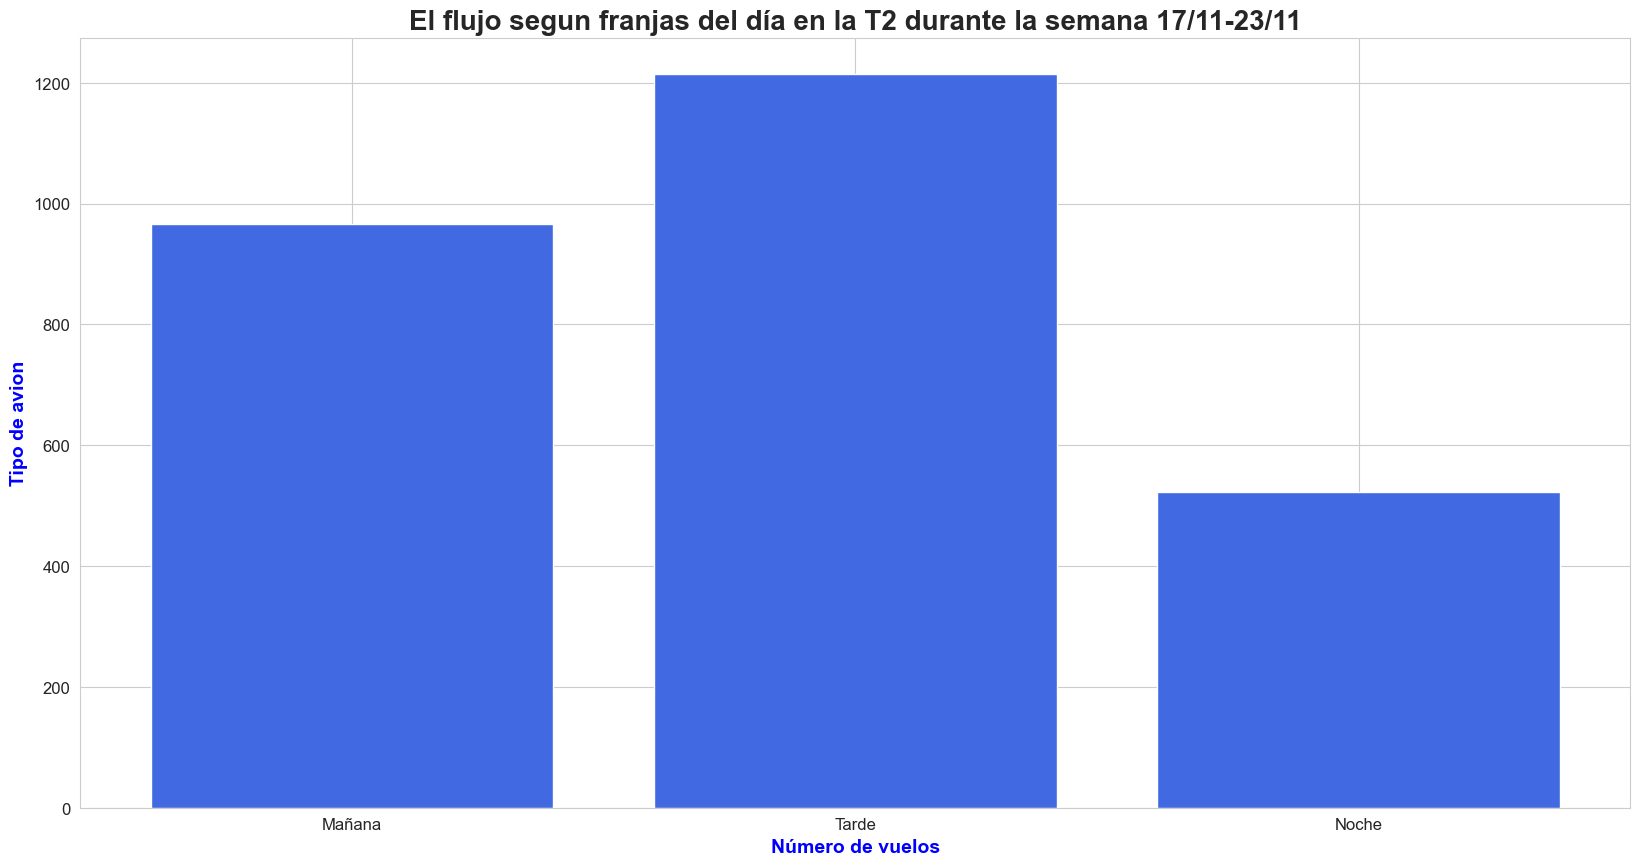

In [177]:
plt.figure(figsize=(20,10))
plt.bar(top5_sorted.index, top5_sorted.values, color="royalblue")

plt.title("El flujo segun franjas del día en la T2 durante la semana 17/11-23/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [178]:
#df.to_csv("vuelos_semanal_limpio1.csv") 

In [179]:
# Ver la capacidad

In [180]:
df_cn = (
    df_easy
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_cn
# ARREGLAR A319 PARA QUE SU CAPACIDAD SEA 156

,Name_company,Aircraft,flight_capacity,count
0,Grupo easy,Airbus A319,156,232
1,Grupo easy,Airbus A320,180,111
2,Grupo easy,Airbus A320neo,186,40
3,Grupo easy,Airbus A321,230,15


In [181]:
df[(df['Aircraft'] == 'Boeing 737-800') & (df['Name_company'] == 'Grupo easy') &
(df['flight_capacity'] == 189)]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [182]:
df_wizz = df[df['Name_company'] == 'Grupo wizz']

In [183]:
df_cw = (
    df_wizz
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

# Corregido
df_cw

,Name_company,Aircraft,flight_capacity,count
0,Grupo wizz,Airbus A320,180,47
1,Grupo wizz,Airbus A320neo,186,4
2,Grupo wizz,Airbus A321,230,85
3,Grupo wizz,Airbus A321neo,239,271


In [184]:
df[(df['Aircraft'] == 'Airbus A320neo') & (df['Name_company'] == 'Grupo wizz') &
(df['flight_capacity'] == 186)]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
444,2025-11-20,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,En hora,186,Airbus A320neo,S,EU,Jueves,Noche
604,2025-11-21,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,En hora,186,Airbus A320neo,R,EU,Viernes,Noche
1048,2025-11-24,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,Retrasado,186,Airbus A320neo,S,EU,Lunes,Noche
2106,2025-12-03,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,En hora,186,Airbus A320neo,S,EU,Miércoles,Noche


In [185]:
df_ryr = df[df['Name_company'] == 'Grupo Ryanair']

In [186]:
df_cy = (
    df_ryr
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_cy
# CorregiFR3180do!

,Name_company,Aircraft,flight_capacity,count
0,Grupo Ryanair,Airbus A320,180,51
1,Grupo Ryanair,Boeing 737 MAX 8,197,314
2,Grupo Ryanair,Boeing 737-800,189,910


In [187]:
df[(df['flight_capacity'] == 156) & (df['Name_company'] == 'Grupo Ryanair')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [188]:
df_t = df[df['Name_company'] == 'Transavia']

In [189]:
df_tr = (
    df_t
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_tr

,Name_company,Aircraft,flight_capacity,count
0,Transavia,Airbus A320neo,186,32
1,Transavia,Airbus A321neo,232,21
2,Transavia,Boeing 737-800,189,49


In [190]:
df[(df['Aircraft'] == 'Airbus A319') & (df['Name_company'] == 'Transavia')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [191]:
df_v = df[df['Name_company'] == 'Volotea']

In [192]:
df_vl = (
    df_v
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_vl
# CORREGIdo !

,Name_company,Aircraft,flight_capacity,count
0,Volotea,Airbus A319,156,30
1,Volotea,Airbus A320,180,61


In [193]:
df[(df['Aircraft'] == 'Airbus A319') & (df['Name_company'] == 'Volotea')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
27,2025-11-17,Volotea,V73573,Asturias (OVD),09:30:00,Retrasado,156,Airbus A319,S,NAC,Lunes,Mañana
108,2025-11-17,Volotea,V73700,Vitoria (VIT),17:15:00,En hora,156,Airbus A319,S,NAC,Lunes,Tarde
150,2025-11-17,Volotea,V72165,Nantes/Atlantique (NTE),20:50:00,Retrasado,156,Airbus A319,R,EU,Lunes,Noche
395,2025-11-20,Volotea,V73573,Asturias (OVD),16:05:00,En hora,156,Airbus A319,S,NAC,Jueves,Tarde
538,2025-11-21,Volotea,V73735,Murcia (RMU),15:15:00,Retrasado,156,Airbus A319,S,NAC,Viernes,Tarde
554,2025-11-21,Volotea,V73573,Asturias (OVD),17:40:00,En hora,156,Airbus A319,S,NAC,Viernes,Tarde
570,2025-11-21,Volotea,V72165,Nantes/Atlantique (NTE),19:30:00,En hora,156,Airbus A319,S,EU,Viernes,Tarde
830,2025-11-23,Volotea,V73573,Asturias (OVD),17:40:00,En hora,156,Airbus A319,S,NAC,Domingo,Tarde
850,2025-11-23,Volotea,V72165,Nantes/Atlantique (NTE),19:30:00,En hora,156,Airbus A319,S,EU,Domingo,Tarde
921,2025-11-24,Volotea,V73573,Asturias (OVD),09:30:00,En hora,156,Airbus A319,U,NAC,Lunes,Mañana


In [194]:
df_e = df[df['Name_company'] == 'Eurowings']

In [195]:
df_ew = (
    df_e
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_ew


,Name_company,Aircraft,flight_capacity,count
0,Eurowings,Airbus A319,150,12
1,Eurowings,Airbus A320,180,24
2,Eurowings,Airbus A320neo,180,1
3,Eurowings,Airbus A321,226,4
4,Eurowings,Airbus A321neo,232,8


In [196]:
df[(df['Aircraft'] == 'Airbus A321') & (df['Name_company'] == 'Eurowings')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
275,2025-11-19,Eurowings,EW521,Cologne-Bonn (CGN),13:25:00,Retrasado,226,Airbus A321,U,EU,Miércoles,Tarde
576,2025-11-21,Eurowings,EW2521,Stuttgart (STR),19:55:00,Retrasado,226,Airbus A321,U,EU,Viernes,Tarde
1017,2025-11-24,Eurowings,EW7521,Hamburg (HAM),19:40:00,En hora,226,Airbus A321,U,EU,Lunes,Tarde
1810,2025-12-01,Eurowings,EW9441,Dusseldorf (DUS),09:45:00,En hora,226,Airbus A321,R,EU,Lunes,Mañana


In [197]:
df_p = df[df['Name_company'] == 'Pegasus Airlines']

In [198]:
df_pg = (
    df_p
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_pg
#Airbus A321

,Name_company,Aircraft,flight_capacity,count
0,Pegasus Airlines,Airbus A320,180,9
1,Pegasus Airlines,Airbus A321,220,15
2,Pegasus Airlines,Airbus A321neo,239,13


In [199]:
df[(df['Aircraft'] == 'Boeing 737 MAX 8') & (df['Name_company'] == 'Pegasus Airlines')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [200]:
df_m = df[df['Name_company'] == 'Air Arabia Maroc']

In [201]:
df_mm = (
    df_m
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_mm

,Name_company,Aircraft,flight_capacity,count
0,Air Arabia Maroc,Airbus A320,174,54


In [202]:
df_n = df[df['Name_company'] == 'Norwegian Air Sweden AOC']

In [203]:
df_nw = (
    df_n
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_nw

,Name_company,Aircraft,flight_capacity,count
0,Norwegian Air Sweden AOC,Boeing 737 MAX 8,189,10
1,Norwegian Air Sweden AOC,Boeing 737-800,189,39


In [204]:
df_l = df[df['Name_company'] == 'Aer Lingus']

In [205]:
df_ln = (
    df_l
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_ln

,Name_company,Aircraft,flight_capacity,count
0,Aer Lingus,Airbus A320,174,30
1,Aer Lingus,Airbus A320neo,186,3


In [206]:
df[(df['Aircraft'] == 'Airbus A320neo') & (df['Name_company'] == 'Aer Lingus')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
780,2025-11-23,Aer Lingus,EI563,Dublin (DUB),11:30:00,En hora,186,Airbus A320neo,W,INT,Domingo,Mañana
1665,2025-11-30,Aer Lingus,EI563,Dublin (DUB),11:30:00,En hora,186,Airbus A320neo,W,INT,Domingo,Mañana
2586,2025-12-07,Aer Lingus,EI563,Dublin (DUB),11:30:00,En hora,186,Airbus A320neo,Y,INT,Domingo,Mañana


In [207]:
df_s = df[df['Name_company'] == 'Air Serbia']

In [208]:
df_sb = (
    df_s
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_sb

,Name_company,Aircraft,flight_capacity,count
0,Air Serbia,Airbus A319,144,22
1,Air Serbia,Airbus A320,174,2


In [209]:
df[(df['Aircraft'] == 'Airbus A320') & (df['Name_company'] == 'Air Serbia')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
2262,2025-12-05,Air Serbia,JU581,Belgrade (BEG),09:55:00,Retrasado,174,Airbus A320,Y,INT,Viernes,Mañana
2674,2025-12-07,Air Serbia,JU585,Belgrade (BEG),20:35:00,En hora,174,Airbus A320,Y,INT,Domingo,Noche


In [210]:
df_j = df[df['Name_company'] == 'Jet2']

In [211]:
df_jt = (
    df_j
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_jt

,Name_company,Aircraft,flight_capacity,count
0,Jet2,Airbus A321neo,232,1
1,Jet2,Boeing 737 MAX 8,189,1
2,Jet2,Boeing 737-800,189,15


In [212]:
df[(df['Aircraft'] == 'Boeing 737 MAX 8') & (df['Name_company'] == 'Jet2')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
508,2025-11-21,Jet2,LS232,Leeds Bradford (LBA),12:00:00,Retrasado,189,Boeing 737 MAX 8,W,INT,Viernes,Tarde


In [213]:
df_b = df[df['Name_company'] == 'Air Baltic']

In [214]:
df_bl = (
    df_b
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_bl

,Name_company,Aircraft,flight_capacity,count
0,Air Baltic,Airbus A220-300,148,21


In [215]:
df[(df['flight_capacity'] == 145) & (df['Name_company'] == 'Air Baltic')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [216]:
df_lx = df[df['Name_company'] == 'Luxair']

In [217]:
df_xlx = (
    df_lx
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_xlx

,Name_company,Aircraft,flight_capacity,count
0,Luxair,Boeing 737-700,141,4
1,Luxair,Boeing 737-800,186,3
2,Luxair,de Havilland Dash 8-400,76,8


In [218]:
df[(df['flight_capacity'] == 142) & (df['Name_company'] == 'Luxair')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [219]:
df_ba = df[df['Name_company'] == 'Bluebird Airways']

In [220]:
df_bla = (
    df_ba
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_bla

,Name_company,Aircraft,flight_capacity,count
0,Bluebird Airways,Airbus A320,180,4
1,Bluebird Airways,Boeing 737-800,189,13


In [221]:
df_sw = df[df['Name_company'] == 'SmartWings']

In [222]:
df_swg = (
    df_sw
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_swg

,Name_company,Aircraft,flight_capacity,count
0,SmartWings,Airbus A220-300,149,5
1,SmartWings,Boeing 737-800,189,7


In [223]:
df[(df['flight_capacity'] == 148) & (df['Name_company'] == 'SmartWings')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [224]:
df_tw = df[df['Name_company'] == "T'Way Air"]

In [225]:
df_twa = (
    df_tw
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_twa

,Name_company,Aircraft,flight_capacity,count
0,T'Way Air,Airbus A330-200,246,6
1,T'Way Air,BOEING 777-300ER,294,6


In [226]:
df[(df['flight_capacity'] == 275) & (df['Name_company'] == "T'Way Air")]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [227]:
df_az = df[df['Name_company'] == "Azerbaijan Airlines"]

In [228]:
df_aza = (
    df_az
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_aza  # correcto a320

,Name_company,Aircraft,flight_capacity,count
0,Azerbaijan Airlines,Airbus A319,122,4
1,Azerbaijan Airlines,Airbus A320,174,1
2,Azerbaijan Airlines,Airbus A320neo,186,7


In [229]:
df[(df['flight_capacity'] == 174) & (df['Name_company'] == "Azerbaijan Airlines")]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
1662,2025-11-30,Azerbaijan Airlines,J246,Baku (GYD),10:45:00,Retrasado,174,Airbus A320,Y,INT,Domingo,Mañana


In [230]:
df_k = df[df['Name_company'] == "Kuwait Airways"]

In [231]:
df_kw = (
    df_k
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_kw

,Name_company,Aircraft,flight_capacity,count
0,Kuwait Airways,Airbus A330-800,235,4
1,Kuwait Airways,Airbus A330-900,278,5


In [232]:
df_tk = df[df['Name_company'] == "Turkish Airlines"]

In [233]:
df_trk = (
    df_tk
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_trk

,Name_company,Aircraft,flight_capacity,count
0,Turkish Airlines,Boeing 737 MAX 8,151,2
1,Turkish Airlines,Boeing 737-800,165,8


In [234]:
df[(df['Name_company'] == "Turkish Airlines")]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
78,2025-11-17,Turkish Airlines,TK608,Ankara (ESB),13:40:00,Retrasado,165,Boeing 737-800,Y,INT,Lunes,Tarde
277,2025-11-19,Turkish Airlines,TK608,Ankara (ESB),13:40:00,Retrasado,165,Boeing 737-800,W,INT,Miércoles,Tarde
520,2025-11-21,Turkish Airlines,TK608,Ankara (ESB),13:40:00,Retrasado,165,Boeing 737-800,W,INT,Viernes,Tarde
970,2025-11-24,Turkish Airlines,TK608,Ankara (ESB),13:40:00,Retrasado,165,Boeing 737-800,Y,INT,Lunes,Tarde
1165,2025-11-26,Turkish Airlines,TK608,Ankara (ESB),13:40:00,En hora,165,Boeing 737-800,Y,INT,Miércoles,Tarde
1403,2025-11-28,Turkish Airlines,TK608,Ankara (ESB),13:40:00,En hora,165,Boeing 737-800,W,INT,Viernes,Tarde
1863,2025-12-01,Turkish Airlines,TK608,Ankara (ESB),14:45:00,En hora,165,Boeing 737-800,W,INT,Lunes,Tarde
2061,2025-12-03,Turkish Airlines,TK608,Ankara (ESB),14:00:00,En hora,165,Boeing 737-800,Y,INT,Miércoles,Tarde
2309,2025-12-05,Turkish Airlines,TK608,Ankara (ESB),14:15:00,En hora,151,Boeing 737 MAX 8,Y,INT,Viernes,Tarde
2480,2025-12-06,Turkish Airlines,TK608,Ankara (ESB),14:50:00,En hora,151,Boeing 737 MAX 8,W,INT,Sábado,Tarde


In [235]:
df_ic = df[df['Name_company'] == "Icelandair"]

In [236]:
df_ice = (
    df_ic
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_ice

,Name_company,Aircraft,flight_capacity,count
0,Icelandair,Boeing 737 MAX 8,160,8
1,Icelandair,Boeing 757-200,184,1


In [237]:
df_se = df[df['Name_company'] == "SunExpress"]

In [238]:
df_sun = (
    df_se
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_sun

,Name_company,Aircraft,flight_capacity,count
0,SunExpress,Boeing 737-800,189,6


In [239]:
df_sky = df[df['Name_company'] == "SkyUp MT"]

In [240]:
df_smt = (
    df_sky
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_smt

,Name_company,Aircraft,flight_capacity,count
0,SkyUp MT,Boeing 737-700,149,6


In [241]:
df_hi = df[df['Name_company'] == "HiSky"]

In [242]:
df_hik = (
    df_hi
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_hik

,Name_company,Aircraft,flight_capacity,count
0,HiSky,Airbus A320,186,7


In [243]:
df_fl = df[df['Name_company'] == "FlyOne"]

In [244]:
df_flo = (
    df_fl
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_flo

,Name_company,Aircraft,flight_capacity,count
0,FlyOne,Airbus A320,180,3
1,FlyOne,Airbus A321,194,3


In [245]:
df[(df['flight_capacity'] == 194) & (df['Name_company'] == "FlyOne")]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
206,2025-11-18,FlyOne,5F5512,Chisinau (KIV),13:30:00,En hora,194,Airbus A321,W,INT,Martes,Tarde
1988,2025-12-02,FlyOne,5F5512,Chisinau (KIV),13:30:00,En hora,194,Airbus A321,W,INT,Martes,Tarde
2301,2025-12-05,FlyOne,5F5512,Chisinau (KIV),13:30:00,Retrasado,194,Airbus A321,W,INT,Viernes,Tarde


In [246]:
df_ar = df[df['Name_company'] == "FLYONE Armenia"]

In [247]:
df_arm = (
    df_ar
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_arm

,Name_company,Aircraft,flight_capacity,count
0,FLYONE Armenia,Airbus A320,180,4


In [248]:
df_az = df[df['Name_company'] == "Azores Airlines"]

In [249]:
df_aza = (
    df_az
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_aza

,Name_company,Aircraft,flight_capacity,count
0,Azores Airlines,Airbus A320neo,186,2


In [250]:
df_ib = df[df['Name_company'] == "Iberojet"]

In [251]:
df_iber = (
    df_ib
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_iber

,Name_company,Aircraft,flight_capacity,count
0,Iberojet,Airbus A350-900,432,3


In [252]:
df_bol = df[df['Name_company'] == "Boliviana de Aviacion"]

In [253]:
df_avi = (
    df_bol
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_avi

,Name_company,Aircraft,flight_capacity,count
0,Boliviana de Aviacion,Airbus A330-200,246,3


In [254]:
df[(df['flight_capacity'] == 246) & (df['Name_company'] == 'Boliviana de Aviacion')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
668,2025-11-22,Boliviana de Aviacion,OB775,Santa Cruz (VVI),13:10:00,Retrasado,246,Airbus A330-200,Y,INT,Sábado,Tarde
1550,2025-11-29,Boliviana de Aviacion,OB775,Santa Cruz (VVI),13:10:00,Retrasado,246,Airbus A330-200,Y,INT,Sábado,Tarde
2464,2025-12-06,Boliviana de Aviacion,OB775,Santa Cruz (VVI),13:10:00,Retrasado,246,Airbus A330-200,Y,INT,Sábado,Tarde


In [255]:
"""
df['Gate'] = df.groupby(
    ['International_flag', 'Name_company', 'Name_Destiny']
)['Gate'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else None)
)

"""

"\ndf['Gate'] = df.groupby(\n    ['International_flag', 'Name_company', 'Name_Destiny']\n)['Gate'].transform(\n    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else None)\n)\n\n"

In [256]:
df.reset_index(drop=True, inplace=True)

In [257]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [258]:
df_moda = df.groupby(['Name_company', 'Type_f', 'Gate']).size().reset_index(name='count')
df_moda.sort_values(['Name_company'])

,Name_company,Type_f,Gate,count
0,AJet 608,INT,W,1
1,Aer Lingus,INT,W,15
2,Aer Lingus,INT,Y,18
3,Air Arabia Maroc,INT,W,14
4,Air Arabia Maroc,INT,Y,40
...,...,...,...,...
75,Volotea,EU,U,13
77,Volotea,NAC,S,19
73,Volotea,EU,R,17
74,Volotea,EU,S,29


## **16 NANS EN GATE/ 6 INT 10 EU /** 
#### 6 INT: (A TRAVES DE LA OBSERVACIÓN)
- 3 GATES FALTANTE, AIR ARABIA -> Y (+ FRECUENTE)
- 2 GATES, RYR -> W
- 1 GATE, WIZZ -> W
#### 10 EU:
- 3 GATES, TRANSAVIA -> U
- 5 GATES, WIZZ -> S
- 2 GATES, RYR -> U

PARA IMPUTAR GATES -> MODA(+ FRECUENCIA)pero CONDICIONAL BASADA EN EL TIPO Y LA COMPAÑIA

In [259]:
"""
import pandas as pd

# Definir la función para obtener la moda (el primer valor si hay empate)
def get_mode(series):
    return series.mode().iloc[0]

# 2. Agrupar por las variables condicionales y usar transform 
#para obtener la moda de cada grupo
# Las columnas condicionales son 'Name_company' y 'Type_f'
moda_condicional = df.groupby(['Name_company', 'Type_f'])['Gate'].transform(get_mode)

# 3. Rellenar los valores NaN de la columna 'Gate' en el DataFrame original 'df'
df['Gate'] = df['Gate'].fillna(moda_condicional)

# Ahora el DataFrame 'df' tiene las Gates imputadas condicionalmente.
df
"""

"\nimport pandas as pd\n\n# Definir la función para obtener la moda (el primer valor si hay empate)\ndef get_mode(series):\n    return series.mode().iloc[0]\n\n# 2. Agrupar por las variables condicionales y usar transform \n#para obtener la moda de cada grupo\n# Las columnas condicionales son 'Name_company' y 'Type_f'\nmoda_condicional = df.groupby(['Name_company', 'Type_f'])['Gate'].transform(get_mode)\n\n# 3. Rellenar los valores NaN de la columna 'Gate' en el DataFrame original 'df'\ndf['Gate'] = df['Gate'].fillna(moda_condicional)\n\n# Ahora el DataFrame 'df' tiene las Gates imputadas condicionalmente.\ndf\n"

In [260]:
df.isna().sum()

fecha_scrapeo      0
Name_company       0
Num_flight         0
Name_Destiny       0
Time_flight        0
flight_state       0
flight_capacity    0
Aircraft           0
Gate               0
Type_f             0
week_day           0
day_time           0
dtype: int64

In [261]:
df[(df['Type_f'] == 'EU') & (df['Name_company'] == 'Grupo wizz')][100:110]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
845,2025-11-23,Grupo wizz,W61478,Warsaw (WAW),19:00:00,En hora,239,Airbus A321neo,U,EU,Domingo,Tarde
847,2025-11-23,Grupo wizz,W43180,Bucharest (OTP),19:05:00,En hora,230,Airbus A321,U,EU,Domingo,Tarde
852,2025-11-23,Grupo wizz,W64406,Sofia (SOF),19:35:00,En hora,239,Airbus A321neo,U,EU,Domingo,Tarde
861,2025-11-23,Grupo wizz,W62096,Krakow (KRK),20:10:00,Retrasado,239,Airbus A321neo,S,EU,Domingo,Noche
864,2025-11-23,Grupo wizz,W67022,Bratislava (BTS),20:20:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche
872,2025-11-23,Grupo wizz,W62378,Budapest (BUD),20:45:00,Retrasado,239,Airbus A321neo,S,EU,Domingo,Noche
882,2025-11-23,Grupo wizz,W43178,Bucharest (BBU),21:20:00,En hora,230,Airbus A321,U,EU,Domingo,Noche
883,2025-11-23,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,En hora,180,Airbus A320,S,EU,Domingo,Noche
885,2025-11-23,Grupo wizz,W46020,Rome (FCO),21:35:00,Retrasado,239,Airbus A321neo,S,EU,Domingo,Noche
892,2025-11-23,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,U,EU,Domingo,Noche


In [262]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [263]:
df_festivos = pd.read_csv("festividades_bcn.csv")
df_festivos

,Unnamed: 0,Date_holiday,Name_holiday,Type_holiday,holiday_eve
0,0,2025-01-01,AÃ±o Nuevo,(e),2024-12-31
1,1,2025-01-06,Reyes,(e),2025-01-05
2,2,2025-04-18,Viernes Santo,(e),2025-04-17
3,3,2025-04-21,Lunes de Pascua Florida,(a),2025-04-20
4,4,2025-05-01,Fiesta del Trabajo,(e),2025-04-30
5,5,2025-06-09,Lunes de Pascua Granada,(L),2025-06-08
6,6,2025-06-24,San Juan,(a),2025-06-23
7,7,2025-08-15,La AsunciÃ³n,(e),2025-08-14
8,8,2025-09-11,Diada Nacional de CataluÃ±a,(a),2025-09-10
9,9,2025-09-24,Mare de DÃ©u de la MercÃ¨,(l),2025-09-23


In [264]:
df_festivos.drop(columns=['Unnamed: 0'] , inplace=True)
df_festivos["Date_holiday"] = pd.to_datetime(df_festivos["Date_holiday"])

In [265]:
df["fecha_scrapeo"] = pd.to_datetime(df["fecha_scrapeo"])

In [266]:
df_festivos["holiday_eve"] = pd.to_datetime(df_festivos["holiday_eve"])

In [267]:
df["festivo"] = df["fecha_scrapeo"].isin(df_festivos["Date_holiday"]).astype(int)
# devuelve True si la fecha está en la tabla de festivos. 

In [268]:
df["Visper_fest"] = df["fecha_scrapeo"].isin(df_festivos["holiday_eve"]).astype(int)
# devuelve True si la fecha está en la tabla de festivos. 

In [269]:
df[(df['fecha_scrapeo'] == '2025-12-07') & (df['Name_Destiny'] == 'budapest (bud)')].head(20)

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest


In [270]:
df[(df['fecha_scrapeo'] == '2025-12-07')].head(20)

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest
2535,2025-12-07,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Domingo,Mañana,0,1
2536,2025-12-07,Grupo Ryanair,FR2834,Charleroi (CRL),06:10:00,En hora,197,Boeing 737 MAX 8,S,EU,Domingo,Mañana,0,1
2537,2025-12-07,Grupo Ryanair,FR2918,Brussels (BRU),06:25:00,Retrasado,189,Boeing 737-800,U,EU,Domingo,Mañana,0,1
2538,2025-12-07,Grupo Ryanair,FR4084,Warsaw (WMI),06:25:00,En hora,189,Boeing 737-800,U,EU,Domingo,Mañana,0,1
2539,2025-12-07,Grupo Ryanair,FR2239,Marrakech (RAK),06:30:00,En hora,189,Boeing 737-800,Y,INT,Domingo,Mañana,0,1
2540,2025-12-07,Grupo Ryanair,FR2507,Cologne-Bonn (CGN),06:40:00,En hora,189,Boeing 737-800,S,EU,Domingo,Mañana,0,1
2541,2025-12-07,Grupo easy,EC7101,"Basel, Switzerland/Mulhouse (BSL)",06:50:00,En hora,156,Airbus A319,R,EU,Domingo,Mañana,0,1
2542,2025-12-07,Grupo easy,EC7191,Glasgow (GLA),07:20:00,En hora,156,Airbus A319,M,INT,Domingo,Mañana,0,1
2543,2025-12-07,Grupo easy,EC8064,London (LGW),07:20:00,En hora,156,Airbus A319,M,INT,Domingo,Mañana,0,1
2544,2025-12-07,Grupo Ryanair,FR6597,Manchester (MAN),07:30:00,En hora,189,Boeing 737-800,W,INT,Domingo,Mañana,0,1


In [271]:
nuevo_indice = len(df)
nuevo_indice

2703

In [272]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2703 entries, 0 to 2702
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha_scrapeo    2703 non-null   datetime64[ns]
 1   Name_company     2703 non-null   object        
 2   Num_flight       2703 non-null   object        
 3   Name_Destiny     2703 non-null   object        
 4   Time_flight      2703 non-null   object        
 5   flight_state     2703 non-null   object        
 6   flight_capacity  2703 non-null   Int64         
 7   Aircraft         2703 non-null   object        
 8   Gate             2703 non-null   object        
 9   Type_f           2703 non-null   object        
 10  week_day         2703 non-null   object        
 11  day_time         2703 non-null   object        
 12  festivo          2703 non-null   int32         
 13  Visper_fest      2703 non-null   int32         
dtypes: Int64(1), datetime64[ns](1), int32(2)

In [273]:
# 2. Usar .loc para asignar los valores a ese nuevo índice.
nueva_fila = ['2025-12-07', 'Grupo Ryanair', 'FR846', 'Milan (BGY)','06:00:00',
              'En hora', 189, 'Boeing 737-800', 'U', 'EU', 'Domingo', 'Mañana', 0, 1]
df.loc[nuevo_indice] = nueva_fila

In [274]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest
0,2025-11-17 00:00:00,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana,0,0
1,2025-11-17 00:00:00,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana,0,0
2,2025-11-17 00:00:00,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0
3,2025-11-17 00:00:00,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana,0,0
4,2025-11-17 00:00:00,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,2025-12-07 00:00:00,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche,0,1
2700,2025-12-07 00:00:00,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche,0,1
2701,2025-12-07 00:00:00,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche,0,1
2702,2025-12-07 00:00:00,Grupo Ryanair,FR9406,Fes (FEZ),23:15:00,En hora,189,Boeing 737-800,Y,INT,Domingo,Noche,0,1


In [275]:
df["fecha_scrapeo"] = pd.to_datetime(df["fecha_scrapeo"])
df["fecha_scrapeo"] = df["fecha_scrapeo"].dt.date

In [276]:
df 

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana,0,0
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana,0,0
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana,0,0
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche,0,1
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche,0,1
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche,0,1
2702,2025-12-07,Grupo Ryanair,FR9406,Fes (FEZ),23:15:00,En hora,189,Boeing 737-800,Y,INT,Domingo,Noche,0,1


In [277]:
df['Name_Destiny'] = df['Name_Destiny'].str.lower()


In [278]:
df = df.sort_values(by=['fecha_scrapeo','Time_flight'])
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest
0,2025-11-17,Grupo Ryanair,FR3180,rome (fco),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana,0,0
1,2025-11-17,Grupo Ryanair,FR846,milan (bgy),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana,0,0
2,2025-11-17,Grupo easy,EC7105,geneva (gva),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0
3,2025-11-17,Grupo Ryanair,FR2233,al aaroui (ndr),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana,0,0
4,2025-11-17,Grupo Ryanair,FR8384,budapest (bud),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,belgrade (beg),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche,0,1
2699,2025-12-07,Grupo wizz,W45154,tirana (tia),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche,0,1
2700,2025-12-07,Grupo Ryanair,FR5220,bologna (blq),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche,0,1
2701,2025-12-07,Grupo wizz,W61706,gdansk (gdn),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche,0,1


In [279]:
# quitar el aeropuerto en () y dejar solo el nombre del destino 
df['Name_Destiny'] = df['Name_Destiny'].str.replace(r'\s+\(.*?\)', '', regex=True)

# 2.Limpia cualquier espacio sobrante al inicio o final
df['Name_Destiny'] = df['Name_Destiny'].str.strip()

In [280]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest
0,2025-11-17,Grupo Ryanair,FR3180,rome,06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana,0,0
1,2025-11-17,Grupo Ryanair,FR846,milan,06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana,0,0
2,2025-11-17,Grupo easy,EC7105,geneva,06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0
3,2025-11-17,Grupo Ryanair,FR2233,al aaroui,06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana,0,0
4,2025-11-17,Grupo Ryanair,FR8384,budapest,06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,belgrade,21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche,0,1
2699,2025-12-07,Grupo wizz,W45154,tirana,22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche,0,1
2700,2025-12-07,Grupo Ryanair,FR5220,bologna,22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche,0,1
2701,2025-12-07,Grupo wizz,W61706,gdansk,22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche,0,1


In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2704 entries, 0 to 2702
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   fecha_scrapeo    2704 non-null   object
 1   Name_company     2704 non-null   object
 2   Num_flight       2704 non-null   object
 3   Name_Destiny     2704 non-null   object
 4   Time_flight      2704 non-null   object
 5   flight_state     2704 non-null   object
 6   flight_capacity  2704 non-null   Int64 
 7   Aircraft         2704 non-null   object
 8   Gate             2704 non-null   object
 9   Type_f           2704 non-null   object
 10  week_day         2704 non-null   object
 11  day_time         2704 non-null   object
 12  festivo          2704 non-null   int64 
 13  Visper_fest      2704 non-null   int64 
dtypes: Int64(1), int64(2), object(11)
memory usage: 319.5+ KB


In [282]:
df["fecha_scrapeo"] = pd.to_datetime(df["fecha_scrapeo"])

In [283]:
#df[(df['fecha_scrapeo'] == '2025-12-07')]
df[(df['fecha_scrapeo'] == '2025-12-04')].head(40)

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest
2109,2025-12-04,Grupo Ryanair,FR8215,london,06:00:00,En hora,189,Boeing 737-800,W,INT,Jueves,Mañana,0,0
2110,2025-12-04,Grupo easy,EC7105,geneva,06:10:00,En hora,156,Airbus A319,R,EU,Jueves,Mañana,0,0
2111,2025-12-04,Grupo Ryanair,FR3976,dublin,06:15:00,En hora,197,Boeing 737 MAX 8,W,INT,Jueves,Mañana,0,0
2112,2025-12-04,Grupo easy,EC7191,glasgow,06:40:00,Retrasado,156,Airbus A319,M,INT,Jueves,Mañana,0,0
2113,2025-12-04,Grupo Ryanair,FR3049,krakow,06:40:00,En hora,197,Boeing 737 MAX 8,U,EU,Jueves,Mañana,0,0
2114,2025-12-04,Grupo Ryanair,FR3028,ibiza,06:45:00,En hora,189,Boeing 737-800,U,NAC,Jueves,Mañana,0,0
2115,2025-12-04,Grupo Ryanair,LW2495,palma de mallorca,07:20:00,En hora,180,Airbus A320,R,NAC,Jueves,Mañana,0,0
2116,2025-12-04,Grupo Ryanair,FR133,berlin,07:25:00,En hora,189,Boeing 737-800,S,EU,Jueves,Mañana,0,0
2117,2025-12-04,Grupo easy,EC7101,"basel, switzerland/mulhouse",07:30:00,En hora,156,Airbus A319,R,EU,Jueves,Mañana,0,0
2118,2025-12-04,Grupo easy,EC7151,milan,07:30:00,En hora,156,Airbus A319,R,EU,Jueves,Mañana,0,0


In [284]:
df[(df['fecha_scrapeo'] == '2025-12-04') & (df['Name_Destiny'] == 'sevilla')].head(20)

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest
2139,2025-12-04,Grupo Ryanair,FR1165,sevilla,10:20:00,En hora,189,Boeing 737-800,U,NAC,Jueves,Mañana,0,0


In [285]:

df.loc[
(df['Name_Destiny'] == 'beauvais'),
'Name_Destiny'
] = 'paris'


In [290]:
#df.to_csv("vuelos_TODO_LIMPIO_2.csv") 

In [287]:
#unir ha salido con programado y en hora 

In [288]:
# if df['Type_f'] =  df(df['Name_Destiny'] == vuelos_INT) = 'INT'
# if df['Gate'] == 'W' or 'y' -> 'internacional' 
# if df['Name_Destiny'] == vuelos nacionales == 'NATION' else == 'EU'

In [289]:
# CRAR VARIABLE DIA DE LA SEMANA(LU,MA, MIE,JUE, VIE, SA, DOM) ESTANDARIZAR FECHA, 